<a href="https://colab.research.google.com/github/cherissaiteriteka32-netizen/CraftHub-project/blob/master/UCU_AI_Tutorial15_16_FlameTree_NLP_LSTM_EQUATIONS_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Ugandan Folktales to Generated Text
## NLP, Sequential Data, RNNs and LSTMs - Practical Notebook

**Course:** Artificial Intelligence  
**Level:** Year 2 Computer Science / Data Science  
**Topics:** Tutorial 15 - Sequential Data: RNNs and LSTMs; Tutorial 16 - Natural Language Processing  
**Estimated class time:** about **90 minutes**

### The central question

> **Can a small LSTM learn enough from an English-language collection of Ugandan folklore to produce text that begins to resemble its patterns?**

In this notebook you will follow one complete NLP pipeline:

$$
\boxed{\text{stories}}
\rightarrow
\boxed{\text{tokens}}
\rightarrow
\boxed{\text{token IDs}}
\rightarrow
\boxed{\text{embeddings}}
\rightarrow
\boxed{\text{LSTM}}
\rightarrow
\boxed{\text{next-token probabilities}}
\rightarrow
\boxed{\text{generated text}}
$$

The objective is **not** to build a modern large language model. The objective is to understand, by running and inspecting a small system, what terms such as **sequence, token, embedding, hidden state, cell state, gate, training, probability and generation** actually mean.

### Source, cultural and historical note

This practical uses narrative prose from **_The Flame Tree and Other Folk-Lore Stories from Uganda_**, taken from the scan-derived TXT supplied for this class and cleaned for teaching.

The collection's preface credits some material to **Sir Apolo Kagwa's _Engero za Baganda_** and other stories to Baganda informants. Therefore, throughout this notebook we describe the material carefully as an **English-language collection/retelling of Ugandan and Baganda folklore**. It should not be treated as a direct Luganda-language corpus or as an untouched transcription of oral performance.

The book is also a historical English-language publication. Some stories contain **period-specific colonial framing, gender stereotypes, violence and other attitudes that should not be treated as neutral descriptions of Ugandan culture**. A language model can learn and reproduce such patterns because they occur in its training data. That is a limitation to notice, not an endorsement of the material.

For consistency, this notebook uses **21 narrative entries**. Three primarily poetic/song entries are not used for language-model training:
- *The Singer*
- *Soliloquy of Old Age in a Banana Garden*
- *Song of a Muhima Herding Cattle in Bugerere*

The corpus is embedded directly in this notebook. **No internet download is required.**

### Learning outcomes

By the end of the practical, you should be able to:

1. explain why text is **sequential data**;
2. distinguish a **token**, **token ID** and **embedding**;
3. explain what an RNN **hidden state** represents conceptually;
4. explain why LSTMs introduce a **cell state** and learned **gates**;
5. identify the input and target in a **next-token prediction** problem;
6. trace tensor shapes through an embedding layer and LSTM;
7. train and evaluate a small LSTM language model;
8. inspect a probability distribution over possible next tokens;
9. explain how repeated next-token prediction becomes **text generation**;
10. use evidence from visualisations and outputs when discussing model behaviour.

### Suggested pacing

| Part | Approx. time |
|---|---:|
| Meet and explore the corpus | 8 min |
| Tokens, vocabulary and sequences | 12 min |
| RNN memory and LSTM gates | 12 min |
| Build and trace the model | 8 min |
| Train and evaluate | 12 min |
| Hidden states, prediction and generation | 13 min |
| TODO submission work | about 25 min |

The notebook is designed for roughly **90 minutes** if you run the guided cells in order and move promptly into the TODO section. You do **not** need to memorise every equation. When an equation appears, focus first on what information is entering, what is being updated, and what the output represents.

## 0. Setup - reproducibility and imports

In [51]:
import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")  # CPU is sufficient and makes results more comparable across students.
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


## 1. Meet the corpus before modelling it

A machine-learning model learns from the data that we provide. Before building a network, we should know:

- **What is one data source?** Here, one source unit is one story.
- **How much text do we have?**
- **Which words and names recur?**
- **Are the stories all the same size?**
- **What kind of language is present?**

This is part of NLP. Data preparation and inspection happen **before** model training.

In [52]:
#@title Embedded corpus (21 stories) - do not edit { display-mode: "form" }
# Cleaned story text embedded directly in the notebook: no network calls.
STORIES = {'The Flame Tree': 'Once upon a time there was a little girl who lived in the village of Si. Her parents had '
                   'no other children, and as she grew older they saw with joy that she was more beautiful '
                   'every day. People who passed through the village saw her and spoke of her beauty until '
                   'everyone in Kyagwe knew that the most lovely girl in the country lived in the village of '
                   'Si - and everyone in the province called her "the Maiden." The Maiden was a gentle, '
                   'sweet child, and she loved all the animals and birds and butterflies and flowers, and '
                   'played with them and knew their language. Her parents were very proud of her, and often '
                   'talked of the time when she should be grown up and marry a great chief with many cows '
                   'and gardens and people, and bring great wealth to her tribe. When the time came to '
                   'arrange her marriage, all the Chiefs came and offered many gifts, as the custom of the '
                   'Baganda is; but the Maiden said, "I will marry none of these rich Chiefs, I will marry '
                   'Tutu the peasant boy, who has nothing, because I love him." Her parents were very '
                   'grieved when they heard this, and would have tried to persuade her, but just then a '
                   'messenger arrived from the Sekibobo to say that the King of Uganda was going to war with '
                   'Mbubi the chief of the Buvuma Islands, and all the chiefs went away to collect their '
                   "people for the King's army. Then the Chief of Si, who is called Kibevu, called all his "
                   'men together, and Tutu the peasant boy went with them. The army marched down to the Lake '
                   'shore to fight the Islanders who came across the blue waters in a fleet of war canoes, '
                   'painted and decorated with horns and feathers and cowry shells and beads. The Maiden was '
                   'very sad when she said good-bye to Tutu. "Be very brave and win glory," she said, "then '
                   'my father will let me marry you, for I will never marry any one else." But when the men '
                   'had marched away and only the women and children were left in the village with the old '
                   'people, the Maiden forgot her brave words and only thought how she could bring Tutu '
                   'safely back. She called to her friend the hawk. "Come and help me, Double-Eye; fly '
                   'quickly to the Lake shore and see my peasant boy - tell him I think of him day and '
                   'night. I cannot be happy till he returns." The hawk knew Tutu well, for often on the '
                   'hillside he had played with the children. The Baganda called him "Double- Eye," for they '
                   'say, that, with one eye he watches the Earth and with the other he sees where he is '
                   'going. The Baganda reached the Lake, and there was a great battle, and Tutu the peasant '
                   "boy was killed by a stone from an Islander's sling; but the Baganda rallied, and drove "
                   'the enemy back to their canoes, and Mbubi beat the retreat drum, and his men returned to '
                   'Buvuma. The hawk flies very quickly, and while he was still a long way off he saw Tutu '
                   'lying where he had fallen on the Lake shore. The soldiers were burying the dead, and the '
                   'hawk watched to see where they would bury the peasant boy of Si, that he might show the '
                   "maiden his grave. The Maiden waited on the hillside for the hawk's return and the "
                   'moments seemed like hours. She called to a bumble bee who was her friend. "Go quickly to '
                   'the Lake side and greet my peasant boy, tell him I wait here on the hillside for his '
                   'return." The bumble bee flew away quickly, and when he reached the Lake shore he asked '
                   'the hawk for news. "The Islanders have fled in their canoes, but Tutu the peasant boy is '
                   'dead, a stone from a sling killed him. I wait to see his grave that I may show it to the '
                   'Maiden." The bumble bee was afraid to go back with the news, so he stayed near the hawk '
                   'and watched. Meanwhile the Maiden waited in a fever of impatience, ever gazing at the '
                   'distant Lake and pacing up and down. She saw a flight of white butterflies playing '
                   'hide-and-seek round a mimosa bush and called to them. "Oh, white butterflies, how can '
                   'you play when my heart is breaking? Go to the Lake shore and see if my peasant boy is '
                   'well." So the white butterflies flew away over the green hills to the Lake and arrived '
                   "on the battlefield just as the soldiers were digging Tutu's grave, and they settled "
                   'sadly down on a tuft of grass, their wings drooping with sorrow, for they loved the '
                   'Maiden who had often played with them in the sunshine. Far away on the Si hills the '
                   'Maiden watched in vain for their return. Filled with fear she cried to the Sun, "Oh, '
                   'Chief of the Cloud Land, help me! take me on one of your beams to the Lake shore that I '
                   'may see my peasant boy and tell him of my love." The Sun looked down on her with great '
                   'pity, for he had seen the battle and knew that Tutu the peasant boy was dead. He '
                   'stretched out one of his long beams and she caught it in her hands, and he swung her '
                   'gently round until she rested on the Lake shore. When she saw the soldiers lifting '
                   'Tutu\'s body to lay it in the grave she cried to the Sun: "Oh, Chief of the Cloud Land, '
                   'do not leave me, burn me with your fire, for how can I live, now that my Love is dead? '
                   '"Then the Sun was filled with pity and struck her with a hot flame, and the soldiers '
                   "were very sorry for her too, and they dug a grave for her next to Tutu's. And when the "
                   'people of Si visited the graves the next year they found a wonderful thing, for a '
                   'beautiful tree had grown out of them with large flame-coloured blossoms which ever '
                   'turned upwards to the sun, and they took the seeds and planted them in their gardens. '
                   'And now the country is full of these beautiful trees which are called Flame Trees, but '
                   "the old people call them Kifabakazi, because the stem is as soft as a woman's heart and "
                   'a woman can cut it down.',
 'The Buffalo Maiden': 'There was once a little girl who lived with her uncle and aunt. Her uncle loved her, '
                       'but the aunt was always unkind to her. Now, this aunt was really a witch, but no one '
                       'knew it. One day she said to her husband: "You must send that little girl away, I '
                       'cannot stand her any more, she is so naughty, but go first to the forest to the old '
                       'wizard who lives there and he will tell you what to do." So the man went to the '
                       'forest, but he did not know that his wife had told the wizard what to say. The '
                       'wizard said: "Take the little girl to the forest and leave her there." Then he was '
                       'sorry for the man, and added: "If you do this, good fortune will come to the child, '
                       'but many years must pass." Very sadly the man returned home. He took a gourd of milk '
                       'and some Indian corn and told his little niece to follow him into the forest. When '
                       'they had walked a long way they sat down to rest, and the child was so tired that '
                       'she fell asleep at once. Then the uncle put down the gourd of milk and the Indian '
                       'corn and went sorrowfully home. When the child woke it was very dark in the forest, '
                       'and she was terrified at the sounds round her and feared the wild animals might come '
                       'and eat her; but she heard a chirping voice in the tree above her, and saw a large '
                       'cricket sitting on a branch just over her head: "Climb up into this tree," said the '
                       'cricket, "and you will find a nice bed to sleep in." So the child climbed up into '
                       'the fork of the tree, and there was a lovely place full of dry leaves, where she '
                       'cuddled down and was soon fast asleep again. The next morning she saw that several '
                       'buffaloes were resting under her tree, and as she was very hungry she thought: "I '
                       'will go and ask the cow buffalo to give me some milk." The buffaloes were very sorry '
                       'for the child left all alone in the Forest, and they said: "You will soon die of '
                       'hunger here - come and live in our kraal in the jungle, and you shall have milk '
                       'every day and a little hut all of your own." So the little girl climbed on the old '
                       "cow buffalo's back, who was the Granny in the herd, and went with her to the kraal "
                       'which was hidden away in the thick jungle. At first she was sad and unhappy and '
                       'homesick. She wanted her uncle, and her friends in the village at home, and the old '
                       'granny buffalo could do nothing to comfort her. Then the great bull buffalo who '
                       'ruled the herd called a council of animals together and said: "How can we make this '
                       'child happy who has come to live with us in the Forest? "The animals were much '
                       'distressed; for they all wanted to be kind. But the child sat and sobbed, for she '
                       'was lonely and homesick. Just then an old tortoise who had been asleep for many '
                       'years, woke up, and came shuffling into the Council. "The child will be quite happy '
                       'if you take away her heart," he said. "For it is the heart of a woman that brings '
                       'all the trouble into the world, if she cannot love she will give no trouble, if she '
                       'has no heart she will be quite happy." So they cut out the little girl\'s heart and '
                       'tied it up in wild plantain leaves and hung it up in a cedar tree, and they built '
                       'her a hut under the cedar tree, and she settled down happily and cried no more, and '
                       'her heart hung far above out of reach where no one could touch it. From that moment '
                       'the child changed, at first the buffalo granny was pleased because she stopped '
                       'crying and was quiet, but soon she grew puzzled for the little girl was so strange. '
                       'Every day she did unkind things and laughed when she hurt the animals. She pushed '
                       'the little cubs into the Forest pools when they came to drink, and she climbed up '
                       "into the trees and threw little birds that couldn't fly out of their nests, and when "
                       'the mothers cried she laughed at them, and clapped her hands. There was one animal '
                       "who had not been at the great bull buffalo's council. The little hare was away at "
                       'the time, on a long journey, but when he returned, and the other animals told him '
                       'about it, he looked very grave. The little Hare knows more about people than any '
                       "other animal, for he often goes to the villages and he understands men's language. "
                       'He watched the little girl, and every day he grew sadder. Years passed by, and the '
                       'child grew up into a beautiful woman: but she had no friends in the Forest, all the '
                       'animals were afraid of her, none of them loved her. If they growled she stared at '
                       "them, and they slunk off, for her eyes frightened them. One day the Sekibobo's men "
                       'were hunting buffaloes, and one of them followed a wounded animal through the jungle '
                       'when, to his surprise, he saw a lovely girl come down the Forest path. When she saw '
                       'the wounded buffalo she laughed and went back, and the man was so frightened that he '
                       'went back the way he had come, and told the other hunters, and they told the Chief. '
                       "Then the Chief sent a party of men to the Forest and they followed the hunter's "
                       "trail and came to the buffaloes' kraal and there they saw a beautiful girl milking a "
                       'buffalo and singing: I am the Buffalo Maiden, The Buffalo Kraal is my home; The '
                       'Jungle Land is my Kingdom, Wherever I will I roam. I hate the golden sunbeams That '
                       'fill the glades with light, I hate the silver moonbeams That chill my hut at night. '
                       'The birds are dumb when they see me, The animals are my foes; For I am the Buffalo '
                       'Maiden, As all the Jungle knows. They were afraid to speak, and they went quietly '
                       "back. Then the Sekibobo went to the Capital and told the Chiefs in the King's "
                       'Council, and the King and all the Princes heard that a beautiful girl lived all '
                       'alone in the depths of the Forest, in a buffalo kraal. There was one Prince braver '
                       'and kinder than the others and he was sorry for the girl, so he took one man with '
                       'him and went to the Forest to find her. When he found her he loved her very much, '
                       'but the girl only laughed at him and threw stones at him. Some of the stones hit '
                       'him, and hurt very much, and every day he grew more and more miserable. One day '
                       'while he was walking in the forest he found a doe with a sharp thorn in its foot. He '
                       'took the thorn out and carried the poor tired creature to its home. The doe was very '
                       'grateful and said: "Tell me what I can do to thank you." And the Prince answered, '
                       '"Tell me how I can make the girl I love love me." The doe was very sorrowful. "You '
                       'will never make her love you, she is unkind and cruel to everyone, but I will ask '
                       "the other animals, and perhaps they can give me advice. So when the doe's foot was "
                       'healed she went to the big grey elephant and asked his advice. "Tell your Prince," '
                       'said the big grey elephant, "that the girl is cruel and unkind, he had better seek a '
                       'wife in the Capital." So the doe went to the lion. "If the Prince has been kind to '
                       'you, he is much too good for the girl," he said; "she is hard and cruel and never '
                       'sheds tears as the women in the villages do." All the animals said the same thing, '
                       'and at last the doe met the little hare and told him her trouble. "It isn\'t her '
                       'fault," said the hare, "they took her heart away from her when she was a little '
                       'girl: how can she be kind without a heart? Let the Prince steal her heart that hangs '
                       'in the cedar tree and then she will love him." So the doe went and told the Prince, '
                       '"You must steal her heart which hangs in the cedar tree above her hut, but you must '
                       'go alone at night." So the Prince went alone through the dark Forest at night and '
                       "came to the buffaloes' kraal. The moonlight was shimmering through the grey shadows "
                       "as he picked his way between the sleeping buffaloes up to the maiden's hut, and "
                       'there above him in the cedar tree hung the heart. He climbed the tree and clasped '
                       'the heart in his arms, and as he did so the girl asleep in the hut below felt a '
                       'great fear. "Some one has touched my heart," she cried. Softly and tremulously she '
                       'opened the door and saw the Prince, and fell at his feet, sobbing "Oh, my Lord, you '
                       'have my heart in your arms, take me too! "So the Prince took her away to the Capital '
                       'and they lived happily together for many years. The big grey elephant called a '
                       'Forest Council together, and they passed sentence on the old tortoise and killed '
                       'him, because his advice had been bad, for this is the law of the Mabira Forest - if '
                       'any animal gives bad advice to the Council, he is killed. And the Forest Council '
                       'sent a messenger to the Prince and told him what they had done. And he was glad; for '
                       'though the heart of a woman causes all the trouble in the world it also brings all '
                       'the joy, and her tears are like the spring rains and make the Earth beautiful.',
 'The Mpa Bana Bird': 'The African cuckoo does not sing Cuckoo, Cuckoo; it sings Cuckoo&oo, Cuckoo&oo, and '
                      'it can sing this song for a whole hour, until everyone in the neighbourhood is tired '
                      'of hearing it, then it flies to another tree, clears its throat and begins again. The '
                      'mother cuckoo is too lazy to build a nest of her own, and to hatch her own eggs. If '
                      'she finds a nice comfortable-looking nest she lays an egg in it and flies away hoping '
                      'the owner will hatch it for her; but she forgets so soon, that she never returns to '
                      'see what has happened to her egg. One day a mother cuckoo found a lovely nest in the '
                      'forest and laid an egg among the four little eggs which were in it already. Then she '
                      'flew away and forgot all about it. When the owner of the nest returned, she was too '
                      'tenderhearted to throw the egg out, so she hatched it with her own. But the young '
                      'cuckoo was so large and hungry that he soon filled up the nest, and one day when the '
                      'mother bird was away looking for food he pushed the four little fledglings out of the '
                      'nest. A wild cat was passing among the bushes down below and gobbled them up as they '
                      'fell. When the mother bird returned she found only the cuckoo in her nest, and she '
                      'searched everywhere for her children crying as she went, "Mpa bana, mpa bana," which '
                      'means, "Give me children, give me children." She searched under the bushes and all '
                      'round her nest and then went all through the forest crying all the time, "Mpa bana, '
                      'mpa bana," till all the other birds and animals knew of her sorrow. When the next '
                      'nesting season came, she laid four more eggs, and never left the young birds after '
                      'they were hatched, but she had got into the habit of singing this song: I left them '
                      'safe in the nest, Mpa bana, mpa bana; Seeking the food that was best, Mpa bana, mpa '
                      'bana; How did the cruel thief come, Mpa bana, mpa bana; Wrecking my joy and my home, '
                      'Mpa bana, mpa bana. The young birds heard it all day long and learnt to sing it; and '
                      'now it has become their tribal song, and they sing it for hours together, and are '
                      'quite as tiresome as the cuckoo who just sings cuckoo&oo, cuckoo&oo, without '
                      'grumbling about it.',
 'The Absent-Minded Bridegroom': 'Once upon a time there was a man called Nagamba, who was very '
                                 'absent-minded. Everybody laughed at him, but he did not mind. He had many '
                                 'friends and was quite a good fellow. At last the time came for his '
                                 'marriage, and he paid the dowry and arranged the feast, and married his '
                                 'sweetheart, and they started on the journey to his house. But as they '
                                 'walked along they came to a place called Nakuse, and Nagamba remembered '
                                 'that a friend of his lived there; so he said to his bride: "Sit here and '
                                 'rest in the shade for a little while, and I will fetch you a cooling '
                                 'drink." When he got to his friend\'s house he found a feast going on and '
                                 'many people he knew were there, and he sat down with them and forgot the '
                                 'poor little bride sitting in the shade waiting for a cooling drink. And '
                                 'the sun went down, and night fell, and still he sat on and talked and '
                                 'joked and sang, and the dawn broke in the east and suddenly the cocks '
                                 'crowed. Nagamba sprang to his feet: "My friends," he cried, "I am married, '
                                 'and my bride sits in the shade waiting for a cooling drink." They all went '
                                 'to find her; but the girl had become tired of waiting and had returned to '
                                 "her father's house, and refused to go back to Nagamba, and as no one else "
                                 'would marry him he remained a bachelor all his life. And now in Uganda '
                                 'this has become a proverb; if a man is absent-minded and forgetful, his '
                                 'friends say: "You will never get a wife; you will have the fate of '
                                 'Nagamba, the absent-minded bridegroom.',
 'The Famine': 'A long time ago a terrible drought visited the countries round the Great Lake, The spring '
               'rains failed, every day the sun rose like a copper ball and made his burning way across a '
               'cloudless sky. No flowers bloomed that spring, and the grass dried upon the hillsides. The '
               'banana trees in the shady gardens looked desolate and sad, their leaves hung down limp and '
               'brown and no heavy bunches of golden fruit filled the air with sweetness. The potato patches '
               'had been baked hard and dry, and no Indian corn had been able to struggle through the hard '
               'ground. At last the people began to dig up the banana roots, and to eat the great coarse '
               'bulbs to keep themselves from starving. The lake sank lower and lower till the tall papyrus '
               'stood high above the water, and the marshy ground was seen for miles among the shallows '
               'round the shore. Great rocks stood out round the falls at Jinja, and the water trickled in '
               'small rivulets over them where every spring the waters of the Great Lake rush and tumble and '
               'roar into the river Nile. Famine and want spread over the land, but the part of the country '
               "that suffered most was Busoga. There was a large herd of elephants which lived in Zibondo's "
               'country, and they wandered from place to place seeking fresh grass and leaves and roots and '
               'finding nothing. At last the chief of the herd spoke. "When I was a calf in the herd, ninety '
               'years ago, I remember a famine like this, and I remember that the Nile was so low that we '
               'found a ford and crossed into the Mabira Forest and found food there; let us go now, and '
               'seek this ford, for the waters of the river are low. So the herd moved off towards the Nile, '
               'and as they went they passed through deserted villages and wasted country and saw the thin '
               'starving animals dragging themselves to the river. The chief of the herd led them straight '
               'to the spot he remembered, and there they saw rocky ground gleaming through shallow water '
               'and knew they had found a ford. There was one cow elephant who was walking with her calf and '
               'cheering him on. "Courage, my child," she said, "we are nearly there. Think of the cool '
               'green glades we shall find in the Mabira Forest, for this pitiless sun can never strike '
               'through the thick creepers on the trees, and the water pools are deep and dark." As she said '
               'this her small eyes fell on a pitiful sight. A mother monkey had carried her baby down to '
               'the river to drink, but she was too weak to lift it. The cow elephant lifted them both with '
               'her trunk and carried them across the ford into the Mabira Forest. The King of the Cloud '
               'Land had seen the distress on the Earth, and as he looked down on Uganda he saw what the cow '
               'elephant did. And his heart was filled with pity for the starving people and animals, and he '
               'called all his clouds together, a great army, and they poured rain on the sunbaked Earth. '
               'And where there had only been hard ground, gardens and fields sprang up, the hillsides '
               'became green with grass and brilliant with flowers, and the Great Lake rose and poured its '
               'waters over the falls, and where the shallows had been round the lake shore, the water was '
               'so deep that it reached to the feathery heads of the papyrus, and the ford across the river '
               'was lost under the tumbling rushing waters. From that time the monkeys have always been the '
               'friends of the elephants, for though they are small they can help them. From their homes in '
               'the tree-tops they can see the hunters coming and they warn the herd. They see the hunters '
               'setting traps and they tell the elephants where they are. And this is why men prefer to hunt '
               'elephants on the plains and hillsides and fear to hunt them in the forests, for they never '
               'know whether the monkeys have seen their plans and have told the herd their secrets.',
 'The Quits of Gomba': 'There was a battle going on round the village of Gomba. In the village there was a '
                       'lame man who had never walked. Every morning he was carried out into the sunny '
                       'courtyard and every evening he was carried back to his house; but the battle was '
                       'raging, and no one remembered the lame man. As he lay in his house he saw a blind '
                       'man passing by, and a sudden thought struck him. He called to the blind man: "Come '
                       'here, my friend, I have something important to tell you." The blind man groped his '
                       'way with his long stick till he stood before the lame man, who said: "Listen, my '
                       'friend, no one has remembered us during the battle, and assuredly we shall die, you '
                       'who are blind, and I who am lame; but I have a plan; Take me on your back, and we '
                       'will escape from the village. I will be eyes to you, and you shall be feet to me." '
                       'The blind man agreed to the plan and hoisted the lame man on his back, and they '
                       'escaped from Gomba. When they reached safety the blind man said: "Give me a reward, '
                       'for I have saved your life." But the lame man said, "Not so, it was I who saved '
                       'yours." They spoke hot and angry words to each other, and at last they decided to '
                       "take the case to the Chief's Council. But when the Chief heard it, he said: There is "
                       'no case; the lame man was eyes to the blind, and the blind man was feet to the lame, '
                       'both have saved their lives, which in itself is a great reward. The words are '
                       'finished." And now this has become a proverb in Uganda. When two men quarrel and '
                       'both of them are in the right (or in the wrong) the people say, "It is a case of the '
                       'Quits of Gomba."',
 'The Dog and the Leopard': 'Once upon a time a leopard who had several cubs hired a dog to be nurse to '
                            'them, but she was very unkind to the dog, who was miserable. The dog was always '
                            'thin and hungry, she only ate what was left over when the leopard and her cubs '
                            'had finished a meal, and that was never much. One day when the leopard was out '
                            'visiting, and the dog was left at home with the cubs, she found some bones in a '
                            'corner and fell upon them ravenously. One of the cubs crept up to look, and a '
                            'bone hit him in the eye and put the eye out. When the dog saw what she had done '
                            'she was very frightened and ran away into the forest. She ran on until she came '
                            'to the house of the old wizard, and then she thought, "I will go and have my '
                            'fortune told." So she went into the house and told the wizard what had '
                            'happened. Now, the old wizard told fortunes by cards, and his cards were bits '
                            'of buffalo hide, sewn over with cowry shells and beads. He got them out of his '
                            "goatskin bag and was just going to tell the dog's fortune when he saw the "
                            'leopard coming down the forest path, and he whispered to the dog: "There is the '
                            'leopard coming here, climb up into that basket which hangs from the roof and '
                            'lie very still." So the dog climbed up into the basket in which the wizard kept '
                            'the bananas he was ripening for beer, and lay quietly down. In a few minutes '
                            'the leopard arrived, and poured out her story to the wizard. "Tell my fortune," '
                            'she said, "that I may know if I shall catch my enemy." The wizard took out his '
                            'cards and spoke. "You will catch your enemy in the spring rains, if she goes '
                            'out in the rain you will catch her. In the sunshine she will be safe, the rain '
                            'will be her downfall. I speak to those that are above, I speak to those that '
                            'are below, let her who has ears hear, let her who hears understand." The '
                            'leopard thanked the wizard and gave him a beautiful white hen as a present, and '
                            'went away home to her cubs. When the dog came down from the basket the wizard '
                            'asked: "Did you understand my warning? "And the dog said, "I understood, sir; I '
                            'will never go out in the rain." The months passed, and one day when the dog was '
                            'out in the forest a heavy shower came on. The spring rains had begun. The dog '
                            'ran in the direction of home, but suddenly she saw an anthill by the road side '
                            'from which the ants were beginning to fly. The dog stopped for a moment to eat '
                            'a few, and then, as the succulent creatures poured out of the anthill, she '
                            "lapped them up with her tongue and forgot all about the wizard's warning, and "
                            'did not see the leopard creeping down the path. The leopard sprang upon the dog '
                            'and killed her. And from that day leopards and dogs are enemies, and a constant '
                            'battle rages between the tribes, for the leopards remember how a dog blinded a '
                            'cub, and the dogs remember the vengeance of the mother leopard in the spring '
                            'rains.',
 'The Leopard, the Hare, and the Monkey': 'Once upon a time a leopard and a hare lived together in one '
                                          'house. One day the leopard said, "Let us go to the village and '
                                          'steal goats." The hare did not want to steal a goat, but he '
                                          'wanted the leopard to go and bring some meat, so he thought of a '
                                          'trick, and agreed to what the leopard said. They started out in '
                                          'opposite directions, but the hare soon doubled back and followed '
                                          'the leopard who crept up the hillside towards a goat which was '
                                          'grazing by itself, and sprang upon it. Then the hare shouted, and '
                                          'the leopard, thinking the goatherds had seen him, dropped the '
                                          'goat and ran away. The hare dragged the goat under some bushes, '
                                          'and after waiting till all was safe and quiet, took it home. The '
                                          'leopard was very surprised and rather sulky. When the meat was '
                                          'nearly cooked the hare went outside the house and shouted. The '
                                          'leopard thought the herdsmen had followed them, and he dashed '
                                          'out, and fled to the forest, and did not return till the morning, '
                                          'by that time the hare had eaten up all the meat-but he told the '
                                          'leopard that the herdsmen had come and taken it all away. This '
                                          'happened several times, till a monkey, who had watched them, told '
                                          "the leopard of the hare's trick, and that evening, instead of "
                                          'running to the forest, he only ran a little way and came back, '
                                          'and found the hare just sitting down to the feast. Although he '
                                          'was very frightened, the hare managed to slip past the leopard '
                                          'and jumped into an anthill which had a large hole in the top. He '
                                          "crouched down and was just out of reach of the leopard's paw. The "
                                          'ants make their home of very hard red earth, so that no storms or '
                                          'rain can wash it away, and the leopard knew better than to risk '
                                          'breaking all his claws trying to dig out the hare, so he shouted: '
                                          '"Foolish creature, I will fill up the hole with fire and burn you '
                                          'inside it; do not think you shall escape my vengeance." He called '
                                          'to a crow who was sitting on a tree near by, "Come and guard my '
                                          'prisoner while I collect firewood." But the crow never does '
                                          'anything for any one, he is too disagreeable; and besides, he did '
                                          'not see why the hare should be burnt in the anthill, so he '
                                          'answered: "I can\'t sit in the sun, the dust gets into my throat '
                                          "and makes me hoarse. I can't guard your prisoner, find someone "
                                          "else.' Just then the monkey who had told the leopard of the "
                                          'hare\'s trick came along. "Oh, my dear friend!" said the leopard, '
                                          '"come and guard the wicked hare whom you helped me to Catch. I am '
                                          'going to burn him in the anthill." So the monkey sat on the top '
                                          'of the anthill while the leopard went to collect firewood. As the '
                                          'monkey sat there he heard the hare munching something. "What are '
                                          'you eating I.he asked. "The white ants are swarming, and I am '
                                          'eating them as they come up," said the hare. "I have never eaten '
                                          'such beautiful ants, they are a miracle of creation." "Give me '
                                          'some," said the monkey, "Lean down into the hole," said the hare. '
                                          '"I bear no malice, and he who eats alone has no joy. I will give '
                                          'you a handful." The monkey leant down into the hole, and the hare '
                                          'threw a handful of dust up into his eyes. The monkey sprang back '
                                          'and rolled off the anthill, and the hare jumped out of the hole '
                                          'and ran away. The crow, sitting on a branch near by, laughed '
                                          'until his throat ached. The monkey wiped the dust out of his eyes '
                                          'and looked ruefully at the anthill. "What shall I do when the '
                                          'leopard returns? "he asked the crow. "Put colocynth seeds into '
                                          'the hole," said the crow, "and put some rubbish on them, and tell '
                                          'the leopard you have begun to build the fire for him." So the '
                                          'monkey did this, and when the leopard came back with the '
                                          'firewood, he piled it up over the hole and they set it alight. A '
                                          'colocynth seed gave a loud pop! "What is that?" said the leopard. '
                                          '"One of his eyes is burnt," said the monkey solemnly. Another '
                                          'seed gave a pop! "That\'s his other eye," croaked the crow. But '
                                          'now the seeds were all thoroughly hot, and they all began popping '
                                          'together, and the crow burst out laughing, and the monkey swung '
                                          'himself up into the tree and laughed until his sides ached, while '
                                          'the leopard fumed with rage, for he knew the monkey was playing '
                                          'some trick. He had to wait until the fire burnt out and the smoke '
                                          'blew away before he could look down into the hole, and then he '
                                          'saw only ashes and twigs and knew that the hare had escaped. And '
                                          'from that day leopards have hated monkeys, and kill them if they '
                                          'meet them in the forest; and the monkeys sleep high up in the '
                                          'trees among the branches that are too slender to bear the '
                                          "leopard's weight, if he should think of climbing up in the night "
                                          'when he goes out hunting.',
 'Musoke the Moon-Boy': 'Years and years ago in Uganda there was a woman whose banana garden bordered the '
                        'high road, and every night the travellers who passed by stole fruit and vegetables '
                        'out of her garden, and this made her very angry. So she took counsel with her old '
                        'nurse, who lived with her, and they dug a ditch, and covered it with sticks, and '
                        'branches, and earth, and leaves, and said to each other: "The next thief who comes '
                        'at night will tumble in." The next evening the herdsman of the Chief was driving '
                        "his cows home to the kraal, when one of them strayed into the woman's garden, and "
                        'fell into the ditch trap and broke its leg. The cowherd was very angry and told the '
                        'Chief, and the Chief sent for the woman, and said, "Why did you set a trap for my '
                        'cow? "When the poor woman explained what she had done the Chief was still more '
                        'angry, and said: "You meant to kill my people. You are a wicked woman." And he '
                        'ordered her to be beaten. The woman implored the Chief to have mercy on her, and he '
                        'said: "Well, you may go home now, I will not beat you, but the next child you have '
                        'shall be mine. If it is a boy I will kill him, if it is a girl you may keep her '
                        'until she is twelve years old, and then she shall be my slave." Very soon '
                        'afterwards the woman had a child, and it was a most beautiful baby boy. She cried '
                        'very much when she thought that her dear little baby would be killed; so she sent '
                        'her old nurse to the Chief to say that it was a girl. The Chief said, "Bring the '
                        'child here that I may see it." When the nurse came back and told the woman, she '
                        'cried more than ever; but just then a stranger passed down the road and turned into '
                        'the garden to ask for a drink of water. She had a little baby tied on her back and '
                        'she carried a roll of mats on her head. The nurse gave her a drink of water and '
                        'said, "We are two women in great trouble." And then she told the stranger the '
                        'story. The stranger said, "I will lend you my little girl baby; go and show her to '
                        'the Chief and save the life of your little boy." So the nurse went again to the '
                        'Chiefs house, and when he saw the baby he said, "..Tell the mother to bring this '
                        'child to me when she is twelve years old." Nobody suspected anything, and when the '
                        'old nurse got home she packed up all their things, and at dawn the next morning '
                        'they set out for Singo with the stranger who had been so kind to them. The years '
                        'passed, and they all lived happily in Singo, and the baby grew into a beautiful '
                        'boy, and they called him Musoke, which means Rainbow. Every day Musoke took his '
                        'goats on to the hillside and played on a reed pipe as he walked, and the goats '
                        'skipped about and jumped, but some were staid old things, and walked sedately. This '
                        'was the song Musoke sang in the morning when he took the goats out before the sun '
                        'was hot. Little black kids, Little white kids, Speckled and striped and brown, I '
                        'love them all And they all love me, Our life is happy and gay and free; I eat and '
                        'sleep, and sing and play, That is our life of every day. Out to the hills when the '
                        'sun is low What we talk of who can know? Home to rest when the sun is high What do '
                        'we dream of, they and I? Little black kids, Little white kids, etc. etc., etc. In '
                        'the evening, when he brought his goats home, he sang another song to them on his '
                        'reed pipe. Come home, come home, little Brothers, The shadows are soft and long. '
                        "Come home, come home, little Brothers, And I'll sing you a slumber song. For the "
                        'plantains are peeled in the kitchen And over the fire they steam, And the housewife '
                        'has saved the peelings for you As luscious and cool and green as they grew. Come '
                        'home, come home, little Brothers, etc., etc. One day a messenger arrived from the '
                        'Chief, who said, "Your little girl must be twelve years old now. The Chief has sent '
                        'for her." The mother was very sad. She sent the old nurse out to the hills where '
                        'Musoke was herding the goats, and said: "Tell my child to come home by the back way '
                        'and to sit in the kitchen hut till I have told him what to do." Then she cooked '
                        'food for the messenger, and said, "When you have eaten you shall see the little '
                        'girl and take her away with you." She dressed Musoke in a little barkcloth and put '
                        'bracelets on his hands, and as she did so she told him the story of his birth, and '
                        'said, "I have saved your life up till to-day, I can do no more. You must use your '
                        'own wisdom "; and she told him a Luganda proverb, "It is no use asking the gods to '
                        'help you if you don\'t mean to run fast." Then she led Musoke to the messenger, and '
                        'said, "Here is my little girl, take her to the Chief." And she gave Musoke a '
                        'present to take, a big hen, and some sem-sem seed in a packet of banana fibre - and '
                        'the old nurse went with them carrying their roll of mats. The Chief was very '
                        'pleased with the little girl and the present she brought, and he gave the old nurse '
                        'a hut, and said, "Take great care of this beautiful child, and see that she learns '
                        'how I like my meals cooked, that in time she may be useful to me." At first Musoke '
                        'was very careful what he did, but he grew careless, and one day he saw a reed pipe '
                        'on the ground, and in a moment he forgot everything and began to play his old goat '
                        'song: Little black kids, Little white kids, Speckled and striped and brown. The '
                        'people heard him in amazement. "Do girls play reed pipes? "they cried. "Who is this '
                        'child?" Musoke was frightened and ran home, and for some time he was very careful; '
                        'but he soon forgot again, and one day he found some boys throwing stones into a '
                        'wild plum tree. And he took the stones and threw them further and higher than any '
                        'of the others. And the boys were amazed, and said: "Can a girl throw? How did you '
                        'learn to throw stones? "Then Musoke was frightened and ran home; but the boys told '
                        'their parents, and everybody began to talk about it, and at last it reached the '
                        'ears of the Chief that there was something queer about the little girl who had come '
                        'from Singo. And he sent to the old nurse and said: "Come to the Council House '
                        'to-morrow with the little girl and I will question you about the strange things she '
                        'does." When the nurse heard this she said to Musoke, "What have you done, my child? '
                        'Now the Chief will find that we have been deceiving him, and he will kill us." That '
                        'night Musoke lay awake wondering what he should say when they questioned him in the '
                        'Council House next day. And then he saw the moonlight shining through the chinks of '
                        'the reed door, and he slipped softly out into the courtyard and sat down by a great '
                        'stone. Everything was beautiful and peaceful round him. The hut threw a deep shadow '
                        'across the courtyard, and behind it the wind sighed and the banana trees threw long '
                        'flickering shadows which reached him now and then, and all round him the crickets '
                        'were chirping, but no wise thoughts came to the poor boy. He sat huddled up in his '
                        'little barkcloth against the big stone, and wondered what he should say in the '
                        'Council House next morning. A big fluffy owl flew past him and stopped in surprise. '
                        '"Why are you not in bed, little girl? "he said. "I am not a little girl," said '
                        'Musoke; and he told his story to the owl. "Ask the Moon to help you," said the owl, '
                        'and flew away. Musoke looked up at the Moon, but she seemed so far away and so cold '
                        'and still. A black bat flew squeaking past him and startled him a little. "What are '
                        'you doing out of doors at night, little girl? "he said. "I am not a little girl," '
                        'said Musoke, and told the bat his story. "Ask the Moon to help you," said the bat, '
                        'and flew on. Musoke looked up again at the Moon; but she seemed still further away, '
                        'and colder and stiller than ever. A big cricket hopped on to the stone by his side '
                        'and gave such a loud chirp that Musoke quite jumped. "Why don\'t you ask the Moon? '
                        '"he said; "only the Moon can help you. But you must stand up, and shut your eyes, '
                        'and stretch your arms high above your head when you speak to her." So Musoke stood '
                        'up and shut his eyes and stretched his arms high above his head; and then he '
                        'laughed, for he felt his muscles swelling and was glad that he was a boy. "Oh, dear '
                        'Moon, have pity on me, and tell me what to do, and how to answer the Chiefs in the '
                        'Council House to-morrow! "Then from far away came a gentle voice. "Little boy, I '
                        'have watched you for many years and I love you dearly. If you go to the Council '
                        'House to-morrow and the Chiefs question you, nothing can save you - will you come '
                        'and live with me in the Cloud Land? Once I had a little boy of my own, but he fell '
                        'out of his cradle into the Great Lake and became an island, and since then I have '
                        'been very lonely, for the stars are far away and never talk to me." Musoke said, '
                        '"How can I come to you right up in the sky? "And the Moon answered, "I will send a '
                        'shower of rain and make a rainbow and you must climb up on that." In a few minutes '
                        'Musoke felt the rain beginning to fall and soon a beautiful rainbow appeared, and '
                        'he said to the cricket: "Tell my old nurse where I have gone, and give my greetings '
                        'to my mother and tell them I am quite safe: I could not play at being a girl any '
                        'more." Then he climbed up on the rainbow, and the Moon took him in her arms and '
                        'laid him in the lovely pearl cradle where her own little boy used to lie, and told '
                        'him not to lean out too far. In the morning no one knew where he had gone, and they '
                        'never found him. But if you look up at the Moon you will see something like a cloud '
                        'lying across it, and in England they call that the "Man in the Moon," but it is '
                        'really Musoke the Moon-Boy in his cradle. Perhaps some day you may see a moon '
                        'rainbow. You may have to watch for many nights, for it is very rarely seen. Some '
                        'people have never seen one at all.',
 'The Elephant That Wanted to Dance': 'Once upon a time the big grey elephant gave a great feast and invited '
                                      'all the animals in the Mabira Forest to come to a beautiful glade '
                                      '(that no man had ever seen), and there they feasted in the moonlight '
                                      'and sang songs and made jokes and danced. There was one little hare '
                                      'who danced better than any other animal, and the big grey elephant '
                                      'said: "Little hare, you are a marvel, you dance like a sunbeam." '
                                      'There was a foolish young elephant at the feast, and he watched the '
                                      'hare dancing to and fro, and up in the air, and he wished he could '
                                      'dance too. He thought so much about it that for some days after the '
                                      'feast he was quite ill and he did not sleep at night, and at last his '
                                      'mother asked him: "Have you any sorrow, my child? "He did not like to '
                                      'tell even his mother what was worrying him, but he went off alone to '
                                      "the hare's house and implored him to teach him to dance. The hare was "
                                      'very surprised, and did not know what to say at first. He looked at '
                                      'the elephant\'s heavy legs, and he said kindly, "One must begin very '
                                      'young to dance, you elephants can do so many clever things which the '
                                      "other animals cannot do. I don't think it would suit your figure to "
                                      'dance." So the young elephant went sorrowfully home. When the other '
                                      'hares heard of his visit they laughed very much, for who had ever '
                                      'heard of an elephant dancing? A week passed and the young elephant '
                                      'invited the hare to his house. He gave him a beautiful dinner and '
                                      'then said: "I must learn to dance. I think of this all day, and I '
                                      'dream of it all night. You must teach me to dance." The hare looked '
                                      'at him in despair. "Your legs are too heavy," he said at last, "your '
                                      'hind legs are much too heavy." Then he went home rather annoyed. '
                                      'Again the elephant sent for him, but this time the hare would not go. '
                                      "He sent a message, saying: ' If you can get a doctor to cut off some "
                                      'of your heavy flanks, so that you will be lighter on your feet, I '
                                      'will try and teach you to dance." The foolish elephant called in an '
                                      'ape, who professed to be a great doctor, and the ape cut all the '
                                      'flesh off his hind legs until only the bones were left and sewed the '
                                      'skin up again. The elephant sent the meat to the hare with a message: '
                                      '"Now you will see that I am in earnest. When my legs have healed up '
                                      'we will begin the dancing lessons." The hares laughed and laughed '
                                      'when they got the message; but they said, "Well, anyway we will have '
                                      'a good feast. "So they sent for all their relations and had a big '
                                      'dinner of elephant steak with sem-sem sauce. A few days afterwards '
                                      'the elephant sent an antelope with a message, "I am very ill indeed, '
                                      'my legs do not heal up, and my doctor thinks he had better sew on the '
                                      'flesh he cut off, so will you please send it back by the antelope." '
                                      'What was to be done? Some of the steak remained over from the feast, '
                                      'but they could not send it back for it had been cooked. The dancing '
                                      'hare said to the antelope, "Stay here, and dine with us, and '
                                      'afterwards we will talk over the business." He said this to gain time '
                                      'and think of a plan. When the antelope tasted the elephant steak, he '
                                      'said, "This is very good meat, what is it? "And the hare said, '
                                      '"Little rock conies that we catch on the hillside, if you like we '
                                      'will hunt some before you go home." The antelope was delighted, and '
                                      'they set off; but the hare led him to a pit trap, and he fell in and '
                                      'was killed. When the antelope did not return the elephant sent a '
                                      'buffalo with the same message, and the hares played the same trick on '
                                      'him. The young elephant was very ill indeed, but when the buffalo did '
                                      'not return he made a last effort and sent a crafty old leopard. None '
                                      'of the forest animals like the leopards very much, for they have such '
                                      'bad manners, and the leopard would not have gone on any message for '
                                      'any one, but he was a little afraid to refuse the young elephant who '
                                      'was a relation of the King of the Forest, so, very grumpily, he '
                                      'agreed to go. The hares were terrified when they saw him coming, and '
                                      'the old mother hare said, "I suppose we must give him dinner; but I '
                                      'don\'t like it a bit, his table manners are awful." The leopard gave '
                                      "the young elephant's message, sniffing and snuffling as he spoke and "
                                      'stopping every now and then to give a little grunt, and the hares '
                                      'kept up their courage all through dinner, and the dancing hare led '
                                      'him to the trap. The leopard had seen many traps, and he sniffed '
                                      'suspiciously round this one. Then he snarled at the hare, "You young '
                                      'villain," he cried, "I can see what you have done to the other '
                                      'messengers." He turned suddenly round in great anger, all his teeth '
                                      'bared, and would have caught the dancing hare, but he slipped away '
                                      'and ran down the hillside. There was a river at the bottom of the '
                                      'hill, and the hare ran in and out of the papyrus clumps where the '
                                      'leopard could not follow him, then he let himself down into a water '
                                      'hole till he was quite wet, and ran back again. The leopard had lost '
                                      'the scent entirely, and was running up and down the bank sniffing and '
                                      'grunting. When he saw the hare so wet that his fur looked like a '
                                      'black rag he thought it was some queer creature that lived in the '
                                      'swamp. "Little wet animal," he cried, "have you seen a hare anywhere '
                                      'about?" "No," answered the hare, "they seldom come here; they live in '
                                      'the forests." "I know that; you are stupid!" said the leopard rudely; '
                                      'and as the sun was setting and he was very hungry, he hurried back to '
                                      'tell the elephant his story; but when he arrived near home, he found '
                                      'much sorrow in the forest, for the poor foolish elephant was dead. '
                                      'And though the hares were really very sorry (for they loved their '
                                      'King, the big grey elephant, whose relation the young one was), yet '
                                      'they felt it really was his own fault for being so silly, and for '
                                      'believing anything an ape said; for no one in the forest, who has any '
                                      'sense, takes the advice of an ape.',
 'The Man Who Knew Too Much': 'Once upon a time there was a man who had a most beautiful garden round his '
                              'house. The soil was so good that everything in his garden was larger and '
                              'better than any in the neighbourhood. His women did all the work, and he just '
                              'showed off his garden to visitors, and because he was bad tempered they '
                              'flattered him, and he became so proud and arrogant that one day he said: '
                              '"When Kintu, the first man, planted a garden he made some big mistakes. Had I '
                              'been there I would have advised him very well, for look, this large pumpkin '
                              'is growing on a small creeping plant, and those small plums on that great '
                              'plum tree. I should have put the pumpkin on the plum tree, and the plums on a '
                              'small plant." And because his friends were afraid of him, they said how wise '
                              'he was and flattered him more than ever. The next day he was sitting under '
                              'his plum tree when a plum dropped down and hit him in the eye, and hurt him '
                              'very much. He had to have his eye tied up and could not bear the light for '
                              'some days. While he was sitting in the dark he had time to think, and he said '
                              'to his friends, "What a foolish man I was to think I knew more than Kintu the '
                              'first man, and how foolish you are to flatter me, for had a pumpkin fallen '
                              'from the plum tree I might have been killed! "After this he became wiser and '
                              'his friends left off flattering him.',
 'The Story of Nsangi and the Apes': 'Once upon a time, far away upon the mountains, there was a village in '
                                     'which the people were very unhappy, for some huge apes came every day '
                                     'and stole little children. There was one poor widow woman who had '
                                     'three little girls, and she hid them away in her house and never let '
                                     'them go out for fear the apes might see them. But every day her fears '
                                     'grew that she might lose her children, as other people in the village '
                                     'had lost theirs, and the little girls were growing weak and thin, '
                                     'because they never went outside their dark house, and never got any '
                                     'fresh air or sunshine. At last the woman went to an old wise tortoise '
                                     'and asked him, "Tell me what I can do to save my children from the '
                                     'apes." And the tortoise said, "Apes never take children who are over '
                                     'twelve years old. If you can hide your little girls till then no apes '
                                     'will touch them, but I should advise you to take them away to a cave '
                                     'in the mountain side where they will get fresh air and room to run '
                                     'about." So the tortoise showed the woman a cave. It was big and airy, '
                                     'and had a little entrance which could be closed by a stone inside and '
                                     'could not be opened from the outside, and there the woman took her '
                                     'three little girls and showed them how to close the entrance when she '
                                     'had gone, and she told them not to open the door to any one except '
                                     'herself. "I will come every day with a basket of food," she said, "and '
                                     'I will sing a song as I come so that you will know it is me. If any '
                                     'one comes to the door who does not sing my song do not open it." The '
                                     'next day the woman brought a basket of food and she sang this song as '
                                     "she climbed' up the mountain path: Three in a cave, Three in a cave, "
                                     'Only three in a cave. All day long while the sun is shining, All night '
                                     'long while the moon is shining, Only three in a cave, Only three in a '
                                     'cave. When the eldest girl was twelve years old the woman took her '
                                     'home and the two younger ones longed for the years to pass when they '
                                     'might leave the cave too (for they had no playmates but the lizards), '
                                     'but it was not safe till they were twelve years old, and the only '
                                     'glimpse they got of the outside world was when they opened the door '
                                     'for their mother, who now sang as she came: Two in a cave, Two in a '
                                     'cave, Only two in a cave. All day long while the sun is shining, All '
                                     'night long while the moon is shining, Only two in a cave, Only two in '
                                     'a cave. Then the day came when the second girl was twelve years old, '
                                     'and only the little one, whose name was Nsangi, was left in the cave. '
                                     'She was lonely and cried very much, for now she had no one but the '
                                     'lizards to play with; but her mother said, "I will come earlier and '
                                     'stay longer with you every day, for now your sisters are at home and '
                                     'can do the work there. Now, there was one old ape who saw the two '
                                     'little girls digging in their garden and wondered where they had come '
                                     'from, for he had never seen children in that house, and he watched and '
                                     'saw the woman go up the mountain path with a basket of food and as she '
                                     'climbed she sang: One in a cave, One in a cave, Only one in a cave. '
                                     'All day long while the sun is shining, All night long while the moon '
                                     'is shining, Only one in a cave, Only one in a cave. When she arrived '
                                     'at the cave Nsangi ran out to meet her, and the old ape hid behind a '
                                     'rock quite near. For several days he listened to the woman singing, '
                                     'and when he thought he had learnt the song he went to the cave door '
                                     'and sang it; but Nsangi heard it inside the cave and was terrified, '
                                     "for the ape's voice was like a hoarse old crow, and her mother's voice "
                                     "was like a bird's. The old ape was very angry, but he went away into "
                                     'the forest and found a young cousin of his who was a great mimic and '
                                     "could copy people's voices. Together they hid behind the rock and "
                                     'listened while the woman sang, Nsangi ran out to meet her mother, and '
                                     'begged her to take her home, for the ape had been to the cave. The '
                                     'woman was very distressed, but she said, "I must go home and tell your '
                                     'sisters, and I will stay with you till you are twelve years old. Your '
                                     'sisters can bring us a basket of food every day. I must go now and '
                                     'make arrangements." When she had gone the apes went after her, '
                                     'sprinkling sharp thorns on the path, and then they hurried to the '
                                     "cave, and the young one sang, copying the woman's voice. Perhaps it "
                                     'was not exactly right, but Nsangi was too frightened to notice little '
                                     'mistakes. She was so glad that her mother had returned so quickly that '
                                     'she opened the door at once. The apes caught her and carried her away, '
                                     'right into the middle of the forest. She cried all the way, and '
                                     'wherever her tears fell little white flowers sprang into blossom. '
                                     'Meanwhile her mother had made all arrangements at home and was '
                                     'returning to the cave, but every now and then she had to stop to take '
                                     'a thorn out of her foot, and this delayed her. At last she reached the '
                                     'cave and found it empty, and the lizards told her what had happened '
                                     'and they told her to follow the trail of the little white flowers '
                                     "which were Nsangi's tears. The poor woman hurried back to the village "
                                     'and told the people what had happened, and the men came out with '
                                     'spears and knives to hunt the apes and they followed the trail of '
                                     'little white flowers right into the middle of the forest, and here '
                                     "they found a big tree which was the King Ape's Palace. Up this tree "
                                     'the apes had carried Nsangi, but as they dragged her up, her foot was '
                                     'cut on a sharp branch and the blood dropped down on to a creeper with '
                                     'thick green leaves, and wherever a drop of blood fell a beautiful '
                                     'crimson flower blossomed, like a convolvulus, only with thick soft '
                                     'petals. The men prepared to make a big fire round the tree, and when '
                                     "the apes saw that their King's palace was going to be burnt they all "
                                     'collected to defend it, and there was a great battle and all the apes '
                                     'were killed, and Nsangi climbed down the big tree and then the men '
                                     'lighted a fire and burnt it to the ground. That was the end of the '
                                     "King Ape's Palace. And since that day apes have been afraid to go near "
                                     'villages, or steal children, for their mothers always tell them what '
                                     "happened to the King Ape's Palace. But the birds and bees carried the "
                                     'seeds of the little white flowers all over the country and the old '
                                     'people call them "Nsangi\'s tears," and you can still see the crimson '
                                     'creeper with flowers like a convolvulus, only with thick soft petals, '
                                     'but you must search for it in the deep forests. Some people have never '
                                     'seen it, but there are some people who never see anything.',
 'The Law Concerning Fortune-Tellers; or, "The Wise Leper"': 'Once upon a time there was a woman who had a '
                                                             'beautiful daughter whom she loved very much, '
                                                             'and she was very anxious that she should find '
                                                             'a nice husband. So many men wanted to marry '
                                                             'the girl that the mother thought it would be '
                                                             'very difficult to choose. There was one very '
                                                             'nice Chief who lived in Kyadondo; but the '
                                                             'mother was so worried about it that at last '
                                                             'she went to a witchdoctor who told fortunes, '
                                                             'and asked him to tell her whether the Kyadondo '
                                                             'Chief would be a good husband for her '
                                                             'daughter. Now, this old witchdoctor wanted to '
                                                             'marry the girl himself, so he made a great '
                                                             'fuss getting out his cards, which were made of '
                                                             'buffalo hide sewn over with shells and beads, '
                                                             'and then he told the woman her fortune. "On no '
                                                             'account let your daughter marry the Kyadondo '
                                                             'Chief."he said, "She will be most unhappy if '
                                                             'she does. There is another man who will make '
                                                             'her a good husband, but I cannot tell you who '
                                                             'he is yet." He then taught the woman to sing a '
                                                             'song which he said would prevent her daughter '
                                                             'from leaving home. It was a bewitched song. So '
                                                             'the woman went home, and all the preparations '
                                                             "for the girl's marriage to the Chief were made "
                                                             'by her guardians, and at last messengers came '
                                                             'from the Chief to take the bride to Kyadondo. '
                                                             'As they started down the road the mother '
                                                             'followed and sang the song the witchdoctor had '
                                                             'taught her: Alone, alone, alone. Cook and '
                                                             'carry and dig, With never a day of ease. My '
                                                             'hut is dark, and the fire is low, And the '
                                                             'night wind sighs in the trees. Stay with me, '
                                                             'daughter mine, Pity my eyes so dim. Who is '
                                                             'this stranger Chief, That you leave me to go '
                                                             "to him? Alone! Alone! Alone! When the bride's "
                                                             'party heard this song they all stopped, and as '
                                                             'the old woman went on singing, they turned '
                                                             'slowly back and followed her to the house, and '
                                                             "the girl went into her mother's hut and the "
                                                             'messengers returned without her to Kyadondo. '
                                                             'The Chief could not understand what had '
                                                             'happened, so he sent other messengers for his '
                                                             'bride, and the same thing happened three '
                                                             'times. The messengers always returned without '
                                                             'the girl, and could not give any account of '
                                                             'what had happened. Everybody in Kyadondo heard '
                                                             "about it, and they said, ' The girl is "
                                                             'certainly bewitched." Now, there was a leper '
                                                             "man living near the Chief's house to whom he "
                                                             'had been very kind, and the leper went to the '
                                                             'Chief, and said, "Send me to fetch the girl, '
                                                             'for I too know something about witchcraft; if '
                                                             'the girl is to blame, I will not bring her, '
                                                             'but if she has only been bewitched by some '
                                                             'wicked person I will surely bring her to you." '
                                                             'So the Chief sent the leper man to fetch his '
                                                             'bride, and he set out, carrying a little '
                                                             'goatskin mat and a reed pipe. When he came to '
                                                             "the woman's house he sat down in the courtyard "
                                                             'outside, on his little mat, and began to play '
                                                             'his pipe. When he had finished they thanked '
                                                             'him for the tune, and he got up and went away, '
                                                             'but he left his little mat in the courtyard. '
                                                             'When he was a little way down the road the '
                                                             'woman noticed the mat, and she said to her '
                                                             'daughter, "Look, the leper has left his mat! '
                                                             'Go after him with it, but do not touch it with '
                                                             'your hands, lift it with a stick and carry it '
                                                             'to him like that." So the girl took a long '
                                                             'reed and lifted the goatskin mat on it. and '
                                                             'hurried after the leper. When she came near '
                                                             'him she called: "Look, my friend, here is your '
                                                             'mat which you left in our courtyard. My mother '
                                                             'has sent me with it." The leper did not '
                                                             'answer; but suddenly he began to sing, and as '
                                                             'he sang the girl followed him down the road '
                                                             'further and further from home. He sang this '
                                                             'song: Great and good is my Chief, Full of '
                                                             'grace are his words, Wealthy the province he '
                                                             'rules, In gardens and flocks and herds. There '
                                                             'shall the girl he loves Be happy beyond her '
                                                             'dreams; Come with me, Maiden, and prove All '
                                                             'that this happiness means. When the woman saw '
                                                             'that her daughter did not return she went to '
                                                             'find her, and saw her far down the road '
                                                             'following the leper and still carrying his '
                                                             'little goatskin mat on the reed. At once she '
                                                             'thought that some trick was being played, and '
                                                             'she hurried after them singing her bewitched '
                                                             'song; but she was old, and her voice was too '
                                                             'feeble to reach so far, and neither the girl '
                                                             'nor the leper heard her. They went straight '
                                                             "on, and came to the Chief's house in Kyadondo. "
                                                             'The Chief was much pleased, and all his people '
                                                             'rejoiced (for they had felt it very much that '
                                                             'he had been slighted by the girl and her '
                                                             'people), and there was a great feast, and the '
                                                             'Chief gave his bride a beautiful house and '
                                                             'many servants, and she was quite happy. '
                                                             'Meanwhile the poor old mother sat mourning in '
                                                             'her hut, thinking that the girl would be very '
                                                             'unhappy and that many misfortunes would come '
                                                             'to her. But as time went on and the girl grew '
                                                             'happier and happier, at last the woman sent a '
                                                             'messenger to the Chief to tell him the whole '
                                                             'story, for she knew that the witchdoctor had '
                                                             'lied to her. The Chief went to the Capital and '
                                                             "told the story in the King's Council, and they "
                                                             'sent for the witchdoctor to hear what he had '
                                                             'to say. "My Lords," he said, "I have done '
                                                             'wrong. I wanted to marry the girl myself, so I '
                                                             "lied to her mother.' Then the King commanded "
                                                             'that the witchdoctor should be killed. And '
                                                             "that day a law was passed in the King's "
                                                             'Council, and it was published throughout the '
                                                             'country and everybody heard it: "That if any '
                                                             'woman goes to a witchdoctor to have her '
                                                             'fortune told, a man of her tribe must go with '
                                                             'her, and hear everything that is said." This '
                                                             'became a custom in Uganda in the old days; but '
                                                             'now there is a new law, and no one may go to a '
                                                             'witchdoctor at all, and if the police find a '
                                                             'man telling fortunes they take him to prison. '
                                                             'But still some people are foolish enough to go '
                                                             'in secret, and have their fortunes told, even '
                                                             'though they know this story.',
 'The Holy Man': 'There was once a Muganda who made great friends with an Arab who came to Uganda to trade '
                 'in ivory, and this Arab, who had travelled in many lands, told him interesting things '
                 'about the people of different races. He told him how in some countries there were men who '
                 'forsook the world and lived alone in great solitude, leading lives of study and silence, '
                 'in which they learnt many things about the Great Spirit and the laws of the Universe, and '
                 'these men became very wise and very holy. When the Muganda heard this, he said, "I also '
                 'wish to be a holy man and spend a life of solitude learning wise things." So he said '
                 'good-bye to all his friends and chose a hilltop where he built a grass hut under a great '
                 'tree, and his wife left a basket of food at the foot of the hill every day, near the '
                 'spring from which he fetched water. He spoke to no one, and no one saw him, and a long '
                 'time passed. Now, an old owl lived in the great tree, and he watched the man build his '
                 'hut, and wondered what he had come there to do, but every day he watched, and nothing '
                 'happened. The man just sat at his hut door and looked out over the hills and valleys until '
                 'the sun set; then he fetched water and his basket of food and shut the door of the hut '
                 'till morning. The owl had lived many years and had seen many strange things, but he '
                 'thought that this man was the strangest of them all, so he decided to ask him what he was '
                 'doing. He flew down and perched on a low branch and greeted the man below. "Who are you? '
                 '"he said, "and what are you doing on my hilltop under my tree? "The man answered: "I am '
                 'going to be a holy man and learn much wisdom, therefore I have come here to live alone and '
                 'learn about the Great Spirit and the wonderful laws of the Universe." "What have you '
                 'learnt so far?" asked the owl. "I haven\'t learnt anything yet," said the man, "except '
                 'that it is very hard to live alone and talk to no one. I am glad you have come to see me '
                 'to-day, perhaps you can give me some advice." The owl ruffled up all his feathers and then '
                 'shook them down again (which is what all birds do when anything amuses them). "Certainly I '
                 'can give you advice," he said; "the best way to learn wisdom is to solve riddles. I will '
                 'ask you a riddle every evening before I go out, and you can think over it till the next '
                 'evening. Every day I will give you a new riddle to guess, and you will become very wise. '
                 'Here is one to begin with to-day, "I have a wife, everything about her is good; what is my '
                 'wife? "The man thought and thought all the next day over this riddle, and at sunset the '
                 'owl told him the answer. "It is a cow. The milk is good, the meat is good, the skin is '
                 'good, the horns are good, the bones are good. There is nothing bad in a cow." Then he gave '
                 'him another riddle, "I have a wife, she is very small, all her children are enormous." '
                 'Again the man thought and thought all day but could make nothing of it, so the owl told '
                 'him the answer. "It is a pumpkin seed. The seed is very small, all the pumpkins are '
                 'enormous." Then he gave him another riddle, "I have a wife, all her children are born '
                 'white, but as they grow up they turn black." The man spent all day thinking over this '
                 'riddle, and in the evening the owl flew down and told him the answer. "It is a wild plum '
                 'tree. The plums are first white, as they ripen they become black." This went on for many '
                 'days, but the man never guessed a riddle, and at last the owl asked, "Do you feel you are '
                 'learning much about the Great Spirit and the wonderful laws of the Universe? " "No," said '
                 'the man. "I am much disappointed. I had hoped to become very wise and holy, but I don\'t '
                 'feel any different, only more lonely than ever." "Then," said the owl, "we will try '
                 'another method. This evening before the sun sets we will go down and sit by the stream and '
                 'see what we can learn there." So they went down the hill- side and sat by some bushes near '
                 'the road from where they could see everything that passed, but were quite hidden. A man '
                 'came down the road carrying a goatskin bag full of cowry shells, and he put this down '
                 'while he filled his gourd with water from the stream, lower down where the water ran clear '
                 'of the road. Another man came past at this moment, and he saw the goatskin bag, and he '
                 'looked up and down the road and saw no one. So he picked up the bag, and ran off as fast '
                 'as he could. Soon another man came down the road driving a sheep before him, and he '
                 'stopped at the stream to let his sheep drink, and while he was doing this the first man, '
                 'who had now filled his gourd with water, came to look for his goatskin bag, and he accused '
                 'the owner of the sheep, saying, "You have stolen my bag of cowry shells." The owner of the '
                 'sheep was very angry, "Do you call me a thief? "he cried. "You pass judgment without any '
                 'reason. I have not seen your goatskin bag." They grew more and more angry and finally they '
                 'fought with their spears, and the owner of the sheep was killed. When the owl saw that, he '
                 'said to the Muganda, "Now, what have you learnt?" The man put his head in his hands, and '
                 'said, "I am bewildered; an innocent man loses his property and becomes a murderer, and '
                 'kills an innocent man, while the thief gets off free. What are the wonderful laws of the '
                 'Universe? "Then the owl said, "I will tell you the answer to this riddle too. The chief '
                 'law of the Universe is, that the sins of the fathers are visited on the children. Now '
                 'listen. "The owner of the goatskin bag had inherited the cowry shells from his father, who '
                 'was a rich man (but he had obtained his riches by killing a stranger secretly, and at '
                 'night, and stealing all his goods). One day the father was found dead in his garden, and '
                 'no one knew who had killed him. The murderer was the owner of the sheep, and justice has '
                 'overtaken him. The man who stole the cowry shells is the son of the murdered stranger, so '
                 'that really he has taken back his own inheritance; but he does not know this, and must be '
                 'brought to justice. This is the way that evil spreads among men. One man is always '
                 "avenging another's deeds. You will do no good by living on a hilltop thinking about it. Go "
                 'back to your village and work, and you will then learn many things about the wonderful '
                 'laws of the Universe. Two duties lie before you. You must bring these two evildoers to '
                 'justice: the man who stole the goatskin bag and the man who killed the owner of the '
                 'sheep." Then the man went home to his village, and next day he told the Chief what he had '
                 'seen, and they brought the two men to the Council, and passed judgment upon them. And the '
                 'man spoke so wisely and gave such good advice that all the chiefs in the Council were '
                 'impressed, and his fame reached the ears of the King. And in after years he became the '
                 "Chief Justice in the King's Council and decided all the important cases, and whenever he "
                 'found a case too difficult for him, he went to the owl on the hilltop for advice, and the '
                 'owl was always pleased to help him, and said, "You see that what I told you is true, '
                 'solving riddles is the road to wisdom. It is a poor thing for a man to sit on a hilltop '
                 "alone, thinking, but it is a great thing to help one's country by bringing evildoers to "
                 'justice.',
 'The Cheats of Kijongo': 'Once there was a man who was a cheat, and he wandered round the country selling '
                          'his goods in markets where no one knew him, and everywhere he cheated. One day he '
                          'collected a lot of rags and bits of soft rubbish and made them into a neat roll, '
                          'and put it all into a small piece of good barkcloth and rolled it up and tied it '
                          'beautifully with broad barkcloth ribbons, until it looked like a roll of real '
                          'good barkcloth yards and yards long. Then he went to a market called Kijongo. '
                          'Now, there happened to come to the same market that day, another man who was a '
                          'cheat. In Uganda the people eat white ants, and like them very much. They taste '
                          'something like shrimps, and you cannot get them all the year round, only when the '
                          'rains begin, twice a year. Then the people put a framework of reeds over the '
                          'anthills and cover this with barkcloth and the ants come out and swarm in the '
                          'barkcloth. Then they are taken to the courtyards, all the wings are removed and '
                          'the ants are fried, they are a great delicacy. The ants have long white wings '
                          "which are thrown away. This cheat had collected a lot of ants' wings, and made "
                          'them into a nice parcel with banana fibre, and on the top he put a few real fried '
                          'ants and went to market, where he met the first cheat trying to sell his '
                          'barkcloth. "Will you buy white ants? "he said. The other man was hungry and said, '
                          '"I don\'t want to buy them, but I will exchange my roll of bark- cloth for them '
                          '"; and they agreed to exchange. Both went home very happy, but imagine their '
                          'surprise when each opened his bargain and found he had been cheated. This has '
                          'become a proverb in Uganda. When a sharp deal is done and the dealer is '
                          'disappointed, the people say, "It is a case of the cheats who met at Kijongo '
                          'market," and if you know this story you understand what they mean.',
 'The Story of the Frog': 'If a frog comes into a House in Uganda and you call a boy and say, "Drive that '
                          'frog away," he will not do so, but he goes and calls a married man who drives the '
                          'frog into the garden, and if you ask the boy: "Are you afraid of frogs? "he will '
                          'say, "No; but it is our custom to call a married man to drive one out of the '
                          'house." Now I will tell you how this became a custom. Long ago there was a widow '
                          'who had a beautiful daughter, and they lived in a round hut in a banana garden. '
                          'One day the girl saw a frog in the road. The poor creature was panting along in '
                          'the sun, for it was midday and there was no shade. Every moment it grew weaker, '
                          'and soon it would have fainted, but the girl picked it up and carried it into her '
                          'shady banana garden and put it down in a pool of water where it soon revived. The '
                          'next day as the girl was peeling bananas in the kitchen she heard a croak at the '
                          'door and there was the frog. "Good morning," he said, "I have come to thank you '
                          'for saving my life. Some day I may be able to repay your kindness." They became '
                          'great friends, and the frog came every day to the kitchen and told the girl many '
                          'stories about the animals. One day he noticed that she looked sad. "What is your '
                          'sorrow? "he said. "Cannot you tell your friend? "So the girl told him. "My '
                          'guardians are arranging for my marriage, and there are four men who want to marry '
                          'me, and I do not know which to choose." The frog said, "Now, I will give you some '
                          'advice. Choose a man who has a kind heart: that is greater wealth than flocks and '
                          'herds and a great chieftainship." But the girl said, "How am I to know which one '
                          'has a kind heart? "Then the frog said, "We will make a little plan and find out. '
                          'I know that you have a kind heart because you saved my life. I will help you to '
                          'choose a man who is kind to animals. If he is kind to animals he will be kind to '
                          'you,"So they arranged a plan, and the girl went to her guardian, and said, "I '
                          'want to choose my husband for myself. I want the four men to come one by one, on '
                          'an appointed day, and I will choose." The guardian consented, and they arranged a '
                          'day, and laid freshly cut grass down in the house, and the girl dressed herself '
                          'in a beautiful barkcloth, and sat on a new mat, and three old ladies of her '
                          "father's tribe sat near her to see that everything was done properly and in "
                          'order. But they knew nothing about the frog. As the first lover entered the porch '
                          'the frog hopped out in front of him and croaked. He drove it away angrily, and '
                          'went into the house, and the girl refused him at once. This happened to three '
                          'young men and as the fourth entered the porch he stepped carefully over the frog, '
                          'and when he had greeted the girl and the old ladies, he said, "There is a frog in '
                          'the porch, does the croaking annoy you? " "Not at all," said the girl; "I like '
                          'frogs." "I am glad of that," said the young man, "for I like frogs too." Then '
                          'they both burst out laughing, which was a very improper thing to do, and shocked '
                          'the old ladies very much; but it made them friends, and the girl decided to marry '
                          'him, and they lived happy ever after. That is why a boy will never drive away a '
                          'frog. He thinks that if he does so the girl he wants to marry will refuse him.',
 'The Hare Who Earned a Cow and a Chieftainship': 'Once upon a time a large family of hares lived together '
                                                  'in a beautiful forest glade. One day the old Chief said, '
                                                  '"I want to make a feast before I die, but I have no meat; '
                                                  'if only someone would give me a cow I would kill it and '
                                                  'give you all a great feast, my children." One young hare '
                                                  'heard the Chief speak, and he said, "I will find a cow '
                                                  'for the feast." The others all laughed at him, "How will '
                                                  'you find a cow? "they cried. "If you were to drive it '
                                                  'through the forest the big animals would all try and take '
                                                  'it from you, and how would you defend it? "But the young '
                                                  'hare said, "I will bring it, for I have a plan; but you '
                                                  'must all help me, and lend me your things if I need to '
                                                  'borrow them. First we must build a round hut and make a '
                                                  'high fence all round it." So all the hares set to work, '
                                                  'and they built around hut and a high fence,-and the young '
                                                  'hare brought a hollow log into the hut, in which a family '
                                                  'of bumble bees had made their home. They were very big '
                                                  'bumble bees, and they all had very loud voices, and as '
                                                  'they all talked together, the noise in the log was like '
                                                  'the noise that a crowd of people makes outside the '
                                                  'Council House when a big case is being tried by the '
                                                  'Chiefs. Then the young hare went across the valley to the '
                                                  'kraal and said to the chief herdsman: "The King has built '
                                                  'a beautiful camp in the forest and is going to make a big '
                                                  'feast; he has sent me to fetch the most beautiful cow in '
                                                  'your kraal; if you do not give it to me you will all be '
                                                  'killed." The herdsmen laughed very much, for they knew '
                                                  'that the young hare was playing a trick on them; but they '
                                                  'said, "You shall have your cow, but you must earn it. '
                                                  'Stay with us for a week, and every evening when we return '
                                                  'to the kraals you must tell us tales of the jungle, and '
                                                  'sing us the forest songs, and sit with us round the fire '
                                                  'at night, and amuse us for a whole week. The hare was '
                                                  'delighted with the idea, and every evening when the '
                                                  'sunset had faded and the soft shadows lay on the hills, '
                                                  'when the cows had been driven into the kraals, and '
                                                  'Kasanke, the little red bird whom the cows love, had been '
                                                  'fed, the herdsmen would settle round the fire and listen '
                                                  'to the wonderful stories which the hare told them, and '
                                                  'the songs of the forest which everyone loves to hear. For '
                                                  'a whole week he lived in the kraals, and the herdsmen '
                                                  'said he had earned his reward, and they gave him a '
                                                  'beautiful cow with long sharp horns, and he set off for '
                                                  'the forest driving it with a long reed. The first animal '
                                                  'he met was the hyena. "I was coming to your house," said '
                                                  'the hare. "The King wishes you to attend him at once, at '
                                                  'his new house in the forest, with the tall fence round '
                                                  'it." So the hyena turned and followed the hare. As they '
                                                  'went through the forest they met the lion and the buffalo '
                                                  'and the leopard, and to each the hare gave the same '
                                                  'message, and they all followed him till they came to the '
                                                  'new house in the forest with the tall fence round it. '
                                                  '"Wait here," said the hare, "till I call you." And he '
                                                  'drove the cow inside the fence. Then he beat the hollow '
                                                  'log with his reed and all the bumble bees buzzed '
                                                  'together, and the animals outside the fence crouched down '
                                                  'in fear, for they thought a crowd of people were with the '
                                                  'King. The other hares were frightened when they saw the '
                                                  'big animals so near. "What are you going to do? "they '
                                                  'cried. "They will soon discover that you have deceived '
                                                  'them, and the buffalo will trample us with her hoofs, and '
                                                  'the lion will eat us, and the hyena will get the scraps." '
                                                  'But the little hare was quite calm. "Bring me a basket '
                                                  'and an axe and a big knife and a pruning knife," he said; '
                                                  'and he went out to the trembling animals, who still '
                                                  'crouched in fear, for the bumble bees had been thoroughly '
                                                  'disturbed and were all saying what they thought about it, '
                                                  'each trying to buzz louder than the rest of the family '
                                                  'put together. "The King is going to give a feast," said '
                                                  'the hare to the trembling animals, and you shall each '
                                                  'have some meat, but you must earn it; the King has a task '
                                                  'for each of you." Then he gave the lion the basket and '
                                                  'told him to fetch water from the stream; and he gave the '
                                                  'buffalo the axe and told him to chop firewood from the '
                                                  'rock; and he gave the leopard the pruning knife, and '
                                                  'said, "Go into the jungle and cut a bamboo without a '
                                                  'joint, the King desires a long straight bamboo without a '
                                                  'joint." And he said to the hyena, "You are to skin the '
                                                  'cow with this knife, but I warn you, if you so much as '
                                                  'lick the meat you will be killed." So the animals went '
                                                  "away, each hoping to earn the King's favour; but when the "
                                                  'lion saw the water pouring through the basket he was '
                                                  'frightened, for he thought it was his fault, and he '
                                                  'dropped the basket and ran away. The buffalo gave a hard '
                                                  'blow at the rock with the axe, and of course the handle '
                                                  'broke. He thought it was his fault, so he dropped the axe '
                                                  'and ran away. The leopard wandered from one clump of '
                                                  'bamboos to another looking for one with no joint, and '
                                                  'finally when the sun was setting he was miles and miles '
                                                  'away, and too tired to go back, and as he was afraid the '
                                                  'King might punish him, he crossed a swamp into a new '
                                                  'Province and made a new home there. Meanwhile the hyena '
                                                  'began to skin the cow. He worked for some time, and then '
                                                  'he licked his paws, and then he could resist the meat no '
                                                  'longer. The hare was hiding near, and he raised the '
                                                  'alarm, "The hyena is eating the King\'s meat! "And he '
                                                  'beat the hollow log with his reed, and all the bumble '
                                                  'bees buzzed together, and the hyena thought the people '
                                                  'were coming out to kill him, so he dropped the knife and '
                                                  'ran away, and did not stop running until he came to '
                                                  'Kavirondo. Then the hares made a great feast for their '
                                                  'old Chief, and they chose the clever young hare to be the '
                                                  'new Chief, and rule the tribe, for they saw that, not '
                                                  'only had he wisdom, but that he was calm in the face of '
                                                  'danger, and this is a great virtue.',
 'The Lion-Girl': 'A long way from Uganda, towards the Congo border, there is a tribe of shepherd people. '
                  'They live in kraals with their cows; they plant no gardens and build no villages, but '
                  'they move from place to place, driving their herds to good pasture and building kraals '
                  'where they find it. The cows have long horns pointing upwards, and as the herds move '
                  'across the plains the horns look like a forest, and although the hoofs make no noise in '
                  'the rich soft soil the horns have a music of their own as they knock together, like many '
                  'castanettes being played down in the plain. There was once a woman of the shepherd tribe '
                  'who had a baby girl, and one day, while the child was crawling on the floor, some '
                  'chickens pecked at it. The child shook itself twice, and the mother saw, to her horror, '
                  'that it became a lion cub, and seized the chickens and ate them up; then it shook itself '
                  'twice and became a little girl crawling on the floor. The woman was afraid to say '
                  'anything to any one about this remarkable child, and as it grew older it ate young calves '
                  'and goats. At last the mother spoke to her little girl: "My child, you make me very '
                  'ashamed of you, for you do such queer things. If any one were to know what you do the '
                  'tribe would certainly kill you, and probably they would kill me too." The little girl '
                  'answered, "I see that you are right. I will not play my tricks any more. I do not want '
                  'you to be ashamed of me." The years passed, and the child grew up, and the time came for '
                  'her marriage. The arrangements were all made, and the bridegroom sent messengers to fetch '
                  'her to his new kraal. When they arrived, the mother said, "I have not yet finished '
                  'dressing the bride. Ask the messengers to sit outside and wait for a little while." Now, '
                  "with the messengers had come an old lady who was a granny in the bridegroom's tribe, and "
                  'she was a very inquisitive old woman, and while the others sat down to wait for the '
                  'bride, she slipped up to the kraal and listened to what the mother said to her daughter '
                  'inside. "My child, you will remember your promise to me and not play any of your tricks." '
                  'And the bride answered: "Do not fear; unless they anger me very much and I forget, I will '
                  'never play those old tricks again." And the mother said, "Even if they anger you, my '
                  'child, do not play those tricks, they frighten me." The old woman listening outside was '
                  'filled with curiosity, and she returned to the waiting messengers wondering very much. '
                  "Then the bride came out, and they took her to her husband's kraal. The lion-girl was a "
                  'good wife and a good mother, and her children played no queer tricks, and the old granny '
                  'watched and waited but nothing happened, and at last she went to the young wife, and '
                  'said, "My friend, pity an old woman, and tell me something I want to know, for I cannot '
                  'be happy by day and I cannot sleep at night, for thinking of what I heard your mother say '
                  'to you about your tricks. What was it you promised not to do? "Then the lion-girl was '
                  'seized with anger, and she shook herself twice and became a full-grown lioness and '
                  'growled at the old woman. And the poor old granny was so frightened that she went quite '
                  'mad, and the lioness shook herself twice and became a woman again, and ran and called the '
                  'people of the kraal: "Come quickly, the poor old granny has gone mad in my hut." Now, the '
                  'old granny had a favourite daughter, and this woman came and took her away and took care '
                  'of her; but every night, in her sleep, the poor old woman talked about the young wife and '
                  'the lioness, until the daughter became suspicious and she told the other women in the '
                  'kraal, and they went together to the lion-girl and asked her: "What happened when the old '
                  'granny went mad in your house, for she talks incessantly about a lioness? "The lion-girl '
                  'was seized with anger, and she shook herself twice and became a full-grown lioness and '
                  'roared at the women, who ran away terrified. Then the lion-girl went away across the '
                  'plain and was lost in the jungle, for she was afraid the men of the tribe would spear '
                  'her, now that her secret was known. All this trouble came about because the old granny '
                  'was so inquisitive.',
 'The Story of the Wonderful Goat': 'Once upon a time there was a man called Kato who had a large herd of '
                                    'goats, and he noticed that one goat was larger than all the others. It '
                                    'grew and grew, and at last it was so enormous that people came from all '
                                    'parts of the Province to see it, and they said, "This goat is a fit '
                                    'present for the King, no one has ever seen its equal." Kato determined '
                                    'to go to the Capital and give his wonderful goat to the King. Now, in '
                                    'the mountains near his village there lived a band of robbers, who used '
                                    'to plunder passers-by and take their goods and sometimes kill them. So '
                                    'Kato was afraid to make the journey to the Capital alone, and his '
                                    'brother agreed to go with him, but first he went to the witchdoctor to '
                                    'have his fortune told, which was a very silly thing to do, as you will '
                                    'see. The robbers had seen the enormous goat and wondered how they could '
                                    'steal it, and, unfortunately, while the chief robber was returning from '
                                    "the village market, he saw Kato going towards the witchdoctor's hut "
                                    '(for he lived alone on a hilltop). The robber knew of a short cut, and '
                                    'he hurried round and arrived first at the hut, and promised the '
                                    'witchdoctor a large reward if he gave certain advice to Kato. When Kato '
                                    'arrived the witchdoctor said, "You are going on a journey, but you must '
                                    'go alone, and until you reach your destination you must eat no salt and '
                                    'drink no banana beer, if you do either of these things misfortune will '
                                    'overtake you." When Kato returned home he told his brother, and he also '
                                    'told his wife to use no salt in the kitchen until he had started for '
                                    'the Capital. Then he made his preparations, and one morning at dawn he '
                                    'started out, driving his goat before him, with a gourd of water tied '
                                    'round his waist by a thong, and a parcel of food in a bag slung over '
                                    'his shoulder and carrying in his hand a spear wrapped round with '
                                    'plantain fibre (for no traveller may carry a naked spear). By midday he '
                                    'had reached the mountains, where the road passed between great boulders '
                                    'of rock, on which the turquoise-blue lizards played all day. He was hot '
                                    'and tired, so he sat down in the shade to rest and eat his dinner. He '
                                    'was so hungry that at first he ate without thinking, but as he felt '
                                    'rested he realised that the dinner was very good, and suddenly he '
                                    "remembered the witchdoctor's warning, and he wondered if there was salt "
                                    'in it. The more he thought over it the more convinced he was that he '
                                    'had eaten salt. He started off again on his journey much agitated, and '
                                    'he had not gone very far when one of the robbers met him, and after '
                                    'giving him a friendly greeting, said, "Why are you driving a pig? That '
                                    'is a very unusual thing to do! "Kato looked at the robber in amazement. '
                                    '"A pig! "he cried. "I have no pigs! This is my wonderful goat I am '
                                    'taking to the Capital to give to the King." "Oh, really!" said the '
                                    'robber; and he said good-bye very quickly and hurried away. Kato was '
                                    'still thinking that the man must have been at a drinking feast to say '
                                    'such an extraordinary thing, when another of the robbers met him. "That '
                                    'is a fine pig!" said the robber. "Where did you get it? " "It is a '
                                    'goat," said Kato; "my wonderful goat that I am taking to the Capital to '
                                    'give to the King." The robber looked very much surprised and went on '
                                    'his way. Three more men of the robber band met Kato on the mountain '
                                    'path, and each one stopped in surprise and made some remark about his '
                                    'pig. Suddenly the witchdoctor\'s warning flashed across his mind: "If '
                                    'you eat salt or drink banana beer misfortune will overtake you." "I '
                                    'have eaten salt, and my goat has been bewitched and become a pig," he '
                                    'cried; and he was so frightened that he left the goat and ran all the '
                                    'way back to the village and his home. When he arrived he told his wife '
                                    'and his brother, "I have been bewitched, I shall surely die." The hot '
                                    'journey in the sun, the fright he had had, and the exhausting run home '
                                    'brought on a fever, and he died. And the robbers took the goat and made '
                                    'a great feast and sent a large joint to the witchdoctor with the '
                                    "present they had promised him; but Kato's family not only lost him and "
                                    'the wonderful goat, but they were more firmly convinced than ever '
                                    'before that the witchdoctor was a marvellous man.',
 'The River Fairy': 'A very long time ago a dreadful plague swept through Uganda, whole provinces were laid '
                    'waste and returned to jungle, for those who had possessed the land had died, and there '
                    'were none to inherit the villages and gardens. In one village everyone died except one '
                    'little girl, and she wandered away down the road till she came to the river Nile. She '
                    'had a very, very, very long name, which means "Glory." She sat down by the river very '
                    'lonely and miserable, and while she was wondering what to do a fisherman came past. The '
                    'child told him her story and he was sorry for her, and took her home with him, and his '
                    'wife was kind to her, and for a little while they lived happily together. But the '
                    'dreadful plague swept on and killed the fisherman and his wife, and again the little '
                    'girl sat desolate and hungry by the river Nile. Suddenly she saw the tail of a great '
                    'fish as it turned in the water. Glory was a little frightened, for she had never seen '
                    'such a huge fish in the river before. To her surprise, as it came nearer, she saw that '
                    "it had a woman's head and that half its body was that of a woman. The fish spoke to "
                    'her: "Do not be afraid, little girl; I have seen you here very often, and I want to be '
                    'your friend. Tell me your sorrow." Glory did not feel frightened any more; she said: "I '
                    'am all alone, everyone I know has died of the plague. I cannot dig and plant a garden '
                    'all by myself, and I cannot live all by myself, and I don\'t know what to do." And she '
                    'began to cry. The fish- woman came nearer and pulled herself up on a rock, and Glory '
                    'stopped crying to look at the beautiful tail covered with golden-brown scales which '
                    'flashed in the sunlight as the drops of water ran off it: "What a beautiful tail you '
                    'have! "she said. "I am the Fairy of the river Nile," said the fish- woman, "and we all '
                    'have beautiful tails in my country." "Where is your country?" asked Glory. The River '
                    'Fairy pulled herself into a more comfortable position on the rock and began: "You see '
                    'the Great Lake which stretches away above the Ripon Falls? when you look at it you see '
                    'only the top of a wonderful land. Under those blue waters, far, far down lies a '
                    'beautiful country. It is not like the country you know, but it has fields of soft green '
                    'seaweed, forests of great sea-palms, sea-flowers of every colour and shade. In the '
                    'middle of this country is the Lake City where the King of the Fishpeople lives, a '
                    'wonderful city of caves cut in the rocks. There are long streets full of blue water, '
                    'and the caves are the homes of the fish-people. There is one cave larger and more '
                    "beautiful than the others, and that is the King's Palace. All the fish-people are his "
                    'servants, we each have our own work, and we all obey his orders. My work is to watch '
                    'the entrance of the river Nile. All day I live in my cave under the Falls, and at '
                    'sunset I swim by a passage through the rock into the Great Lake above, and go to give '
                    "my day's report to the King of the Lake City. Very early in the morning I come back, "
                    'and at dawn I am in my cave again at work. There are other fairies who guard the '
                    'entrance of rivers which flow into the Great Lake, but mine is the only river which '
                    'flows out of it. My river dashes over the Falls and hurries away to the Rapids, and on '
                    'and on, through deserts and plains till it reaches another Great Sea." "I should like '
                    'to see your cave and your Lake City," said Glory. "Can you swim?" asked the River '
                    'Fairy. "No," said Glory, "but I could sit on your back. The River Fairy laughed. "I am '
                    'afraid that would not do, for we should have to swim under the water, and you would '
                    'lose your hold and be drowned. Unless you consent to become a fish-maiden you can never '
                    'see the Lake City, and my cave under the Falls." "How can I become a fish-maiden?" '
                    'asked Glory. "It needs a great deal of courage for a mortal to join us. I should have '
                    'to cut off your feet, and from them a tail would grow." Glory looked down at her little '
                    'brown feet and dug her toes in and out of the soft sand, and said: "I don\'t want my '
                    'feet cut off." "I must not stay any longer now," said the River Fairy. "I will be here '
                    'again at daybreak." And she slipped off her rock into the foaming water and disappeared '
                    'under the Falls. When Glory was left alone she felt very unhappy and longed for the '
                    'River Fairy to come back. She was very hungry too, and went to look for some food; but '
                    'the gardens were empty and over-grown, and she could hardly find any fruit. Every now '
                    'and then she looked down at her little brown toes, and said to herself: "I don\'t want '
                    'my feet cut off." She watched the big red sun drop down behind the hills, and quickly '
                    'the darkness fell round her. She crept into her cold, empty hut, and shut the reed '
                    'door, and tried to get warm under the barkcloths; but the night was damp and foggy, and '
                    'she shivered all alone. She heard the owls hooting to each other, outside, and the bats '
                    'squeal as they hung on to the porch of the hut for a minute or two on their way to '
                    'hunt, and poor little Glory sobbed bitterly, worn out with cold and hunger and '
                    'loneliness. Suddenly she sat up. "I will give up my little brown feet and go and live '
                    'with my kind friend the River Fairy," she said to herself. She drew aside the reed '
                    'door, and the frightened bats fled squeaking away into the shadows. She huddled her '
                    'little barkcloth round her and crept down the path to the river, but just as she was '
                    'reaching the bank a huge form loomed out of the mist and a cow-hippo came puffing and '
                    'blowing and snorting up the path. Glory hid behind a bush and did not dare to move '
                    'until she saw the dawn begin to break. Streaks of light flashed quickly across the sky, '
                    'the bats darted backwards and forwards, the birds began to twitter and wake, and '
                    'suddenly the sun rose. Glory hurried down to the river, and there sat her friend the '
                    'fish-woman on the same rock, her golden-brown tail catching the rays of the rising sun. '
                    '"Oh, dear River Fairy," she cried, "I have changed my mind! I want to come and live in '
                    'your cave and be your little girl." Then she gave such a start that she nearly fell '
                    'into the river, for she heard the same puffing and blowing and snorting coming down the '
                    'path. "It is only my great friend the cow-hippo," said the River Fairy. The huge '
                    'hippopotamus stopped and looked at the child: "I thought all the mortals had died," she '
                    'said. "Only this little girl is left," said the River Fairy, "and she wants to become a '
                    'fish-maiden and live with me." "Very wise of her," said the cow-hippo; "but she looks '
                    'very hungry." Poor little Glory was quite worn out with cold and hunger and the long '
                    'hours spent on the river bank, and when she tried to get up she fainted. The River '
                    'Fairy and the cow-hippo did everything they could, for they were much distressed, they '
                    'laid her in the warm sunshine on the soft sand and rubbed her hands and feet. "We must '
                    'get her some food," they said to each other. "I have only raw sweet potatoes," said the '
                    'cow-hippo, "and she can\'t eat them uncooked, for I have often seen the fires which '
                    'mortals make. If we could get some sweet bananas she might eat those." By this time the '
                    'sun was well up and the whole world was awaking to the life of a new day. A '
                    'cheeky-looking monkey swung himself down by a branch and screamed: "How have you slept? '
                    'How have you slept, Hippo and Fish-People." "Come here at once," commanded the '
                    'cow-hippo; and the monkey turned a somersault and landed on the ground. "Do you know '
                    'the golden sweet bananas that mortals eat?" asked the cow-hippo. "Of course I do," said '
                    'the monkey, "I have eaten bunches of them myself." "Then go and fetch a bunch at '
                    'once"said the cow-hippo. The monkey scratched his head, then he looked up at the sun '
                    'and blinked his eyes, then he scratched his shoulders and said meekly: "Did you ask me '
                    'to do anything? " "Now, listen to me," said the cow-hippo firmly, "you are to go very '
                    'quickly, and fetch a bunch of golden sweet bananas." "Where from?" asked the monkey. '
                    '"From where they grow," said the cow-hippo. A flight of grey parrots had come over from '
                    'the nearer islands in search of food, and as they rested for a moment on a tree near, '
                    'they heard the conversation. One of them flew down and said to the cow-hippo: "It is '
                    'absolutely useless to send the monkey on any errand alone, he will simply forget what '
                    'he has set out to do. We will go with him and see that he brings the bananas." "I '
                    'don\'t want you," said the monkey sulkily; but in a minute he began to laugh and jump '
                    'about and dance and forgot that he was offended. All the animals know how silly the '
                    'monkeys are in this way, but they forgive them many things because they are so funny. '
                    'The monkey went off with the parrots and every time he stopped to play they shrieked at '
                    'him: "Remember the bananas." And at last they brought him back safely with a big bunch '
                    'of ripe golden fruit, and Glory ate them until she was hungry no more. Then she cuddled '
                    'down in a nook in the river bank and went fast asleep. While she slept, the cow-hippo '
                    'and the River Fairy watched over her, and when she woke they asked her: "Do you still '
                    'want to be a fish-maiden? "And Glory looked at her little brown feet and replied: "Yes; '
                    'to-day I will come to you. I cannot go back to my cold hut any more." Then the River '
                    'Fairy gave her some seaweed to eat. It tasted very bitter, but as soon as she had eaten '
                    'it she fell asleep, and while she slept the River Fairy bound her legs together with '
                    'broad bands of seaweed and cut off her little brown feet with a sharp shell, and at '
                    'once a little tail appeared growing from them. Then she slipped into the water and '
                    'carried Glory to her cave under the Falls, and laid her on a lovely soft bed of '
                    'seaweed. There she slept for a whole week and every day her tail grew more beautiful, '
                    "and when she woke it looked like mother o' pearl. She was very hungry when she woke "
                    'after her long sleep, and the River Fairy gave her seaweed and sea-fruit to eat, and '
                    'now it did not taste bitter, for she had become a fish-maiden and could open her eyes '
                    'under water and swim about and turn her tail in the white foam. Then the River Fairy '
                    'took Glory to the Lake City and presented her to the King of the Fish-People. They swam '
                    'down the blue streets bordered by caves and sea-palms; beautiful sea-plants and flowers '
                    "were on every hand, and then they reached the King's Palace, and bowed before the King. "
                    'The King was an old, old man who had ruled the Fish-People for hundreds of years. He '
                    'looked earnestly at the little girl and spoke: "Little Fish-maiden, you are to live '
                    'with the River Fairy and guard the Falls of the Nile. You are to learn her work so that '
                    'in years to come you too may help us in keeping our beautiful Lake Country pure and '
                    'clean, that the water which dashes over the Falls may carry greetings from the Great '
                    'Lake to the Great Sea which lies far away to the North." And now in Uganda, when the '
                    "sun has set and the fires are lighted in the fishermen's huts near the river Nile, and "
                    'the people have eaten their evening meal and gather round the fire, they tell stories; '
                    'perhaps a fisherman will say: "Once I saw a big fish near the Falls, as big as a woman, '
                    'with a head and shoulders and arms like a woman." And the others will say: "How '
                    'wonderful! how wonderful! "But in their hearts they think: "He is lying, he did not see '
                    'this fish." But the fisherman is not lying, for he has seen Glory, the Fish-maiden, who '
                    'is now the River Fairy and guards the Ripon Falls. Here the Great Lake sends its blue '
                    'waters over the rocks, and they hurry away foaming towards the Rapids, and on and on '
                    'over the deserts and plains until they reach the Great Sea which lies far away to the '
                    'North.',
 'The Royal Puff Adders of Budo': 'Outside the main gate of the Lubiri (as the dwelling of the King of '
                                  'Uganda is called) stands a round grass hut. In it burns a fire, and it is '
                                  'the duty of a special Chief to see that this fire never goes out during '
                                  "the King's lifetime. In the old days, when the King died the Katikiro "
                                  'announced to the people, "The fire has gone out." Then the Chiefs chose a '
                                  'new King from among the Princes and killed all the others to prevent a '
                                  'rebellion. (These customs have died out, but the fire still burns in the '
                                  'little grass hut near the gate of the Lubiri, and if you go there you '
                                  'will see it.) When the Chiefs had chosen a Prince they took him to Budo '
                                  'Hill. On this hill there are some great trees, they can be seen for many '
                                  'miles round, for they stand out clear against the sky. Under these trees '
                                  'a little hut was built, and here the young King had to pass the night '
                                  'alone, before the coronation ceremonies. A long time ago a certain King '
                                  'of Uganda died and a young Prince was chosen to succeed him, and was '
                                  'taken by the Chiefs to Budo Hill. He entered the hut under the sacred '
                                  'trees and prepared to keep the vigil. The night fell, and the hut was in '
                                  'complete darkness. All around him was silence broken only by the sounds '
                                  'of the night, the chirping of a cricket or the occasional squeak of a '
                                  'bat. The young King sat alone and meditated on the life that lay before '
                                  'him. Suddenly he heard a rustle in the grass walls of the hut and fear '
                                  'gripped him, every hair seemed to stand on end, for he knew that a snake '
                                  'had crept into the hut and that he was alone with it in the darkness. The '
                                  'boy was no coward, and he would have faced a big animal with courage. But '
                                  'a snake is the foe of every man, and brave men fear to meet one in the '
                                  'dark. He sat still not daring to move, and suddenly he heard a hissing '
                                  'voice near him say: "Young King, put out your hand and lay your fingers '
                                  'on my head, for I wish to talk with you, and I am deaf, and can only hear '
                                  'you through the touch of your fingers on my head." Trembling with horror '
                                  'the boy obeyed, and in the dark he groped for the flat chilly head of the '
                                  'snake and laid his fingers on it. Immediately the snake spoke again. "I '
                                  'am the King of the Puff Adders. Budo Hill is our tribal home. Many of us '
                                  'have wandered into the other provinces, but we come here to die in our '
                                  'old age. Everywhere that men see us they kill us, for they fear our '
                                  'poison, but we have not killed your people in anger. We are deaf, and '
                                  'cannot hear the approaching footsteps of man; when they tread on us we '
                                  'defend ourselves." The young King listened in silence, and then asked: '
                                  '"What do you wish me to do? " "I ask you as a favour to grant us a '
                                  'refuge. Send a command throughout the country that no man is to kill a '
                                  'puff adder on Budo Hill, then we shall have a refuge and a place of '
                                  'safety and we will be your servants and serve you well." "How will you '
                                  'serve me?"asked the King. "Can snakes do work? " "Not the same sort of '
                                  'work as men, but we can be very useful to you, for we can foretell the '
                                  'future better than all the witchdoctors, for it is we who give them their '
                                  'knowledge. If you make friends of us the witchdoctors can never harm '
                                  'you." The young King was silent, thinking what he would do, for he feared '
                                  'the witchdoctors, and would gladly have rid himself of their tyranny. At '
                                  'last he spoke: "I will give the command you wish as soon as I am '
                                  'proclaimed King, and this Hill of Budo shall be your refuge and place of '
                                  'safety; but you must give me some proof of your words, for how do I know '
                                  'that you are not lying? "The King of the Puff Adders thanked him in the '
                                  'same low hissing voice, and then began: "Young King, I will tell you the '
                                  'future of your country. Mark my words well, for all that I tell you will '
                                  'surely come to pass. You are proud and arrogant, and you have much to '
                                  'learn. You will learn much as the years pass, but your people will call '
                                  "you, ' He who causes the tears to flow.' You have much wisdom, and you "
                                  'will make good laws and benefit your country, and you will regret the '
                                  'hardness and cruelty of your youth. Strangers will visit your land and '
                                  'teach you many things, some bad and some good. But the day will come, '
                                  'young King, when your Chiefs will come and tell you that notable '
                                  'strangers have arrived in Uganda, and the Chiefs will ask you: "Shall we '
                                  'kill these men, who are different to any men we have seen before? \' "On '
                                  'your answer will depend the whole future of your country, for these men '
                                  'will be the forerunners of a great force which your sons and your '
                                  'grandsons will not be able to resist. They will teach you new wisdom and '
                                  'new work, and they will bring new gods before whom the witchdoctors will '
                                  'disappear. Test these strangers by whatever means you will, but know '
                                  'this, that on your treatment of them the generations to come will judge '
                                  'you wise or foolish. What will you do that day? "The King said: "If I '
                                  'receive them well and they are the forerunners of a great force, they '
                                  'will eat my kingdom." "They will not eat your kingdom," answered the puff '
                                  'adder, "but they will rule over your land, your sons and your grandsons '
                                  'shall be Kings of Uganda but in a new era - one of which your ancestors '
                                  'never dreamed. What will you do? " "If I kill them, what will happen?" '
                                  'asked the King. "More of their countrymen will follow, but on your '
                                  'treatment of these first comers the future of your land depends." The '
                                  'King was silent for a long time then he said sullenly: "I will give up my '
                                  'country to no man, but when these strangers arrive I will receive them '
                                  'kindly." In the morning the Chiefs came and the young King left his hut, '
                                  'and after the coronation ceremonies were over and he entered on his new '
                                  'duties, to the surprise of all the Chiefs his first proclamation was '
                                  'this, that no man should kill a puff adder on the Hill of Budo. The years '
                                  'passed in wars and short times of peace. The young King was proud and '
                                  'arrogant, and though he made good laws and governed well he was so cruel '
                                  'and hard that his people called him, "He who causes the tears to flow." '
                                  'Arabs visited Uganda and brought many new things and new customs, and new '
                                  'cruelties followed in their wake. One day the Chiefs came to the King and '
                                  'said: "Some strangers have arrived from the South; they are not Arabs, '
                                  'and they are different to any men who have come here before. Shall we '
                                  'kill them? "The King heard their words in silence, he sat with bowed head '
                                  'lost in thought. Vividly before him grew the memory of a night long ago '
                                  'when he had sat in a dark hut on Budo Hill with his fingers on the head '
                                  'of a puff adder. Again he heard the hissing voice as it said: "Know this, '
                                  'that on your treatment of them the generations to come will judge you '
                                  'wise or foolish. What will you do that day? "Silently the Chiefs knelt '
                                  'before the King waiting for him to speak. His reign passed before him in '
                                  'one clear picture after another. He had made his country great, he had '
                                  'made wise laws, he had been hard and cruel but strong, the puff adder had '
                                  'spoken truly. Again he heard the question, "What will you do? "Slowly he '
                                  'raised his head, but he did not look at the waiting Chiefs, his eyes '
                                  'seemed to look far beyond them into the future. "Receive these strangers '
                                  'kindly," he said in a low voice. "Bring them here to me, and let no man '
                                  'do them any harm." Many years have passed since those old days. The great '
                                  'trees still stand on the Hill of Budo, and can be seen for many miles '
                                  'round. The hilltop has been cleared and houses and gardens stand where '
                                  'before was only jungle, and in making this change many puff adders were '
                                  'killed by the workmen, for men had long since forgotten the first '
                                  'proclamation made by a young King in the days gone by. Yet to-day, if you '
                                  'visit the spot under the great trees where once the hut built for a '
                                  "King's vigil stood, you must walk warily, for a gleam of red and gold in "
                                  'the grass will warn you that the puff adders still hold to their ancient '
                                  'refuge and claim the privilege once granted by a King to live on the Hill '
                                  'of Budo.'}

print(f"Narrative stories embedded: {len(STORIES)}")
assert len(STORIES) == 21


Narrative stories embedded: 21


### What was cleaned?

The original scan-derived TXT contains front matter, page numbers, running page headers, illustration material, page-signature letters and advertisements after the stories. The embedded teaching corpus removes those technical artefacts and repairs obvious line-break/OCR problems that would otherwise create artificial tokens.

We **preserve**:
- story wording as far as the supplied source allows;
- local names and place names;
- dialogue;
- punctuation;
- repeated narrative expressions.

The source itself is OCR-derived, so a small number of historical spellings or less-obvious transcription imperfections may still remain. This is also a useful NLP lesson: real text data often requires auditing before modelling.

In [54]:
story_stats = pd.DataFrame({
    "Story": list(STORIES.keys()),
    "Words": [len(text.split()) for text in STORIES.values()],
    "Characters": [len(text) for text in STORIES.values()],
}).sort_values("Words", ascending=False)

print("Approximate corpus words:", story_stats["Words"].sum())
display(story_stats.reset_index(drop=True))

Approximate corpus words: 20552


,Story,Words,Characters
0,The River Fairy,2237,11616
1,Musoke the Moon-Boy,1923,9615
2,The Buffalo Maiden,1667,8418
3,The Royal Puff Adders of Budo,1557,7942
4,The Holy Man,1415,7153
5,The Story of Nsangi and the Apes,1280,6433
6,The Hare Who Earned a Cow and a Chieftainship,1170,5816
7,The Elephant That Wanted to Dance,1132,5791
8,"The Law Concerning Fortune-Tellers; or, ""The W...",1100,5667
9,The Flame Tree,1079,5538


### Visualisation 1 - How large is each story?

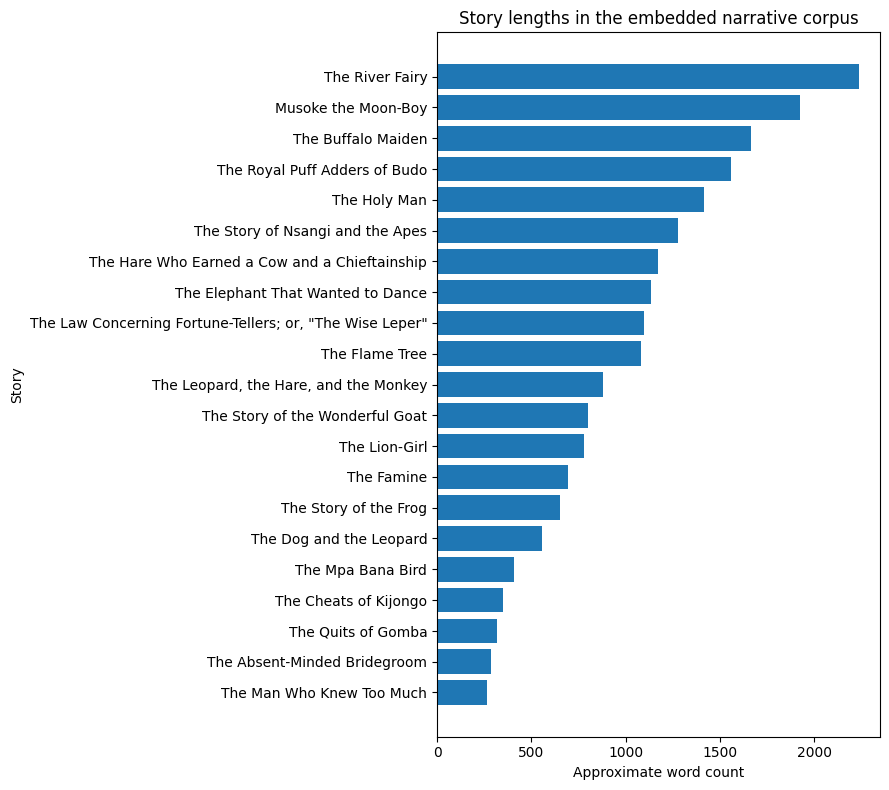

In [55]:
ordered = story_stats.sort_values("Words", ascending=True)
plt.figure(figsize=(9, 8))
plt.barh(ordered["Story"], ordered["Words"])
plt.xlabel("Approximate word count")
plt.ylabel("Story")
plt.title("Story lengths in the embedded narrative corpus")
plt.tight_layout()
plt.show()

**Interpretation:** the dataset is not one uniform block. Some stories are much longer than others. If we split text carelessly, long stories could dominate both training and testing. Later we will split by **whole story**, not by randomly mixing overlapping windows from every story.

In [56]:
sample_title = "The Dog and the Leopard"  # a training story; final test stories remain unused by model fitting
sample_text = STORIES[sample_title]
print(sample_title.upper())
print("-" * len(sample_title))
print(sample_text[:900] + " ...")

THE DOG AND THE LEOPARD
-----------------------
Once upon a time a leopard who had several cubs hired a dog to be nurse to them, but she was very unkind to the dog, who was miserable. The dog was always thin and hungry, she only ate what was left over when the leopard and her cubs had finished a meal, and that was never much. One day when the leopard was out visiting, and the dog was left at home with the cubs, she found some bones in a corner and fell upon them ravenously. One of the cubs crept up to look, and a bone hit him in the eye and put the eye out. When the dog saw what she had done she was very frightened and ran away into the forest. She ran on until she came to the house of the old wizard, and then she thought, "I will go and have my fortune told." So she went into the house and told the wizard what had happened. Now, the old wizard told fortunes by cards, and his cards were bits of buffalo hide, sewn over with cowry shell ...


### Checkpoint

Before continuing, answer mentally:

1. Is one **story** the same thing as one **training example** for our language model?
2. Why might story boundaries matter when creating a test set?

**Reveal:** A whole story is a source document. Later, a training example will be a short sequence of tokens from inside a training story. We keep test stories separate from model fitting so that final evaluation uses narrative material the model did not train on.

## 2. What does a computer receive from language?

Humans see a sentence. A neural network receives numbers.

Consider:

> **The little hare went to the forest.**

A simple word-level tokenizer might produce:

$$
[\text{the},\ \text{little},\ \text{hare},\ \text{went},\ \text{to},\ \text{the},\ \text{forest},\ .]
$$

A **token** is one unit processed by the model. Modern systems often use subword tokens, but a word-level tokenizer is easier to inspect in a beginner practical.

Our teaching tokenizer deliberately:
- converts text to **lowercase**, so capitalization information is discarded;
- keeps common punctuation as tokens;
- splits hyphenated forms around the hyphen.

That simplicity makes every preprocessing step visible, but it is not the only valid way to tokenize language.

In [77]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[.,!?;:()\"--]")

def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())

example_sentence = "The little hare went to the forest."
example_tokens = tokenize(example_sentence)

print("Text:  ", example_sentence)
print("Tokens:", example_tokens)
print("Number of tokens:", len(example_tokens))

Text:   The little hare went to the forest.
Tokens: ['the', 'little', 'hare', 'went', 'to', 'the', 'forest', '.']
Number of tokens: 8


### Token order matters

If we keep the same words but destroy their order, the meaning and grammar can change.

$$
(w_1,w_2,w_3,\ldots,w_T)
$$

is a **token sequence** because position matters. Text, speech, sensor measurements and many time series are sequential for the same general reason: later information can depend on earlier information.

In [58]:
rng = random.Random(7)
scrambled = example_tokens[:-1].copy()
rng.shuffle(scrambled)

print("Original :", " ".join(example_tokens))
print("Scrambled:", " ".join(scrambled + ["."]))

Original : the little hare went to the forest .
Scrambled: the forest to the went little hare .


### Visualisation 2 - A sequence has positions

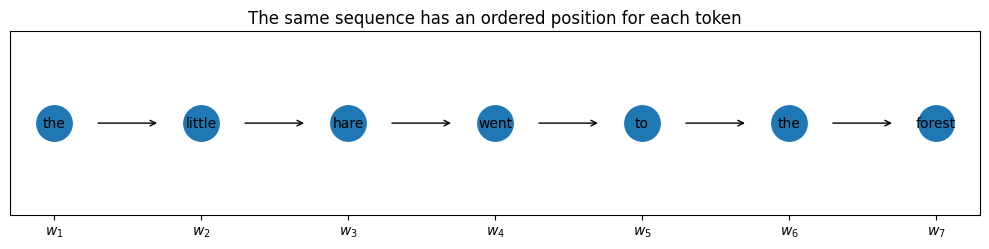

In [59]:
tokens_for_plot = example_tokens[:-1]
x = np.arange(len(tokens_for_plot))

plt.figure(figsize=(10, 2.6))
plt.scatter(x, np.zeros_like(x), s=650)
for i, tok in enumerate(tokens_for_plot):
    plt.text(i, 0, tok, ha="center", va="center")
    if i < len(tokens_for_plot) - 1:
        plt.annotate("", xy=(i+0.72, 0), xytext=(i+0.28, 0),
                     arrowprops=dict(arrowstyle="->"))
plt.yticks([])
plt.xticks(x, [f"$w_{i+1}$" for i in range(len(tokens_for_plot))])
plt.ylim(-0.45, 0.45)
plt.title("The same sequence has an ordered position for each token")
plt.tight_layout()
plt.show()

## 3. Explore the corpus vocabulary

In [60]:
all_tokens = []
for text in STORIES.values():
    all_tokens.extend(tokenize(text))

token_counts = Counter(all_tokens)
print("Total tokens including punctuation:", len(all_tokens))
print("Unique token types:", len(token_counts))
print("Most common 20 tokens:")
print(token_counts.most_common(20))

Total tokens including punctuation: 23701
Unique token types: 2131
Most common 20 tokens:
[('the', 1740), (',', 1301), ('and', 1171), ('.', 803), ('"', 604), ('a', 534), ('to', 532), ('he', 375), ('of', 297), ('in', 274), ('was', 269), ('you', 241), ('i', 217), ('she', 208), ('her', 206), ('they', 203), ('for', 174), ('it', 164), ('that', 159), ('said', 156)]


### Visualisation 3 - Most frequent raw tokens

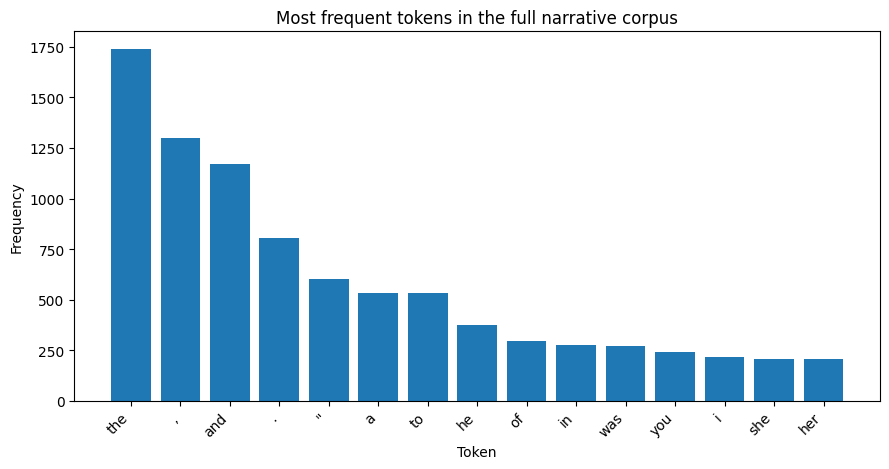

In [10]:
top_raw = token_counts.most_common(15)
labels, values = zip(*top_raw)

plt.figure(figsize=(9, 4.8))
plt.bar(labels, values)
plt.ylabel("Frequency")
plt.xlabel("Token")
plt.title("Most frequent tokens in the full narrative corpus")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Many of the most frequent tokens are words such as **the**, **and**, **to**, **a** and punctuation. These are not useless: grammar depends on them. We therefore **keep them for model training**.

For exploration only, however, removing common function words can make recurring story vocabulary easier to see.

> **Methodological note:** the plots in this section describe the supplied collection. They do not define the model vocabulary or tune the model. The vocabulary used for modelling is built later from the **training stories only**.

In [11]:
STOPWORDS = {
    "the","and","to","a","an","of","in","he","she","it","was","that","they","his","her",
    "had","for","but","with","as","on","at","is","were","so","him","this","not","be",
    "from","when","there","one","all","their","them","who","would","said","then","up",
    "out","very","what","my","you","i","we","me","into","by","have","has","do","did",
    "will","are","your","our","can","could","should","shall","may","might","must","does",
    "been","being","if","or","because","which","while","where","how","why","than","some",
    "any","no","more","most","only","just","again","now","here","after","before",
    ".",",",";",'"',":","!","?","-","-","(",")"
}
content_counts = Counter(t for t in all_tokens if t not in STOPWORDS and len(t) > 2)
top_content = content_counts.most_common(20)
top_content

[('little', 101),
 ('girl', 79),
 ('man', 76),
 ('day', 74),
 ('down', 67),
 ('went', 66),
 ('old', 64),
 ('great', 61),
 ('hare', 56),
 ('come', 55),
 ('away', 54),
 ('told', 53),
 ('king', 51),
 ('chief', 48),
 ('came', 47),
 ('forest', 47),
 ('woman', 46),
 ('home', 46),
 ('saw', 43),
 ('people', 43)]

### Visualisation 4 - Frequent content words

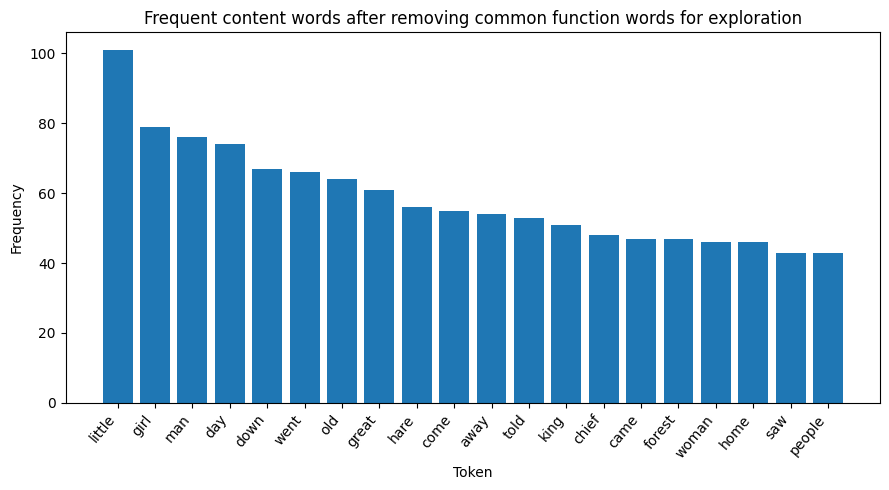

In [12]:
labels, values = zip(*top_content)
plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.ylabel("Frequency")
plt.xlabel("Token")
plt.title("Frequent content words after removing common function words for exploration")
plt.xticks(rotation=50, ha="right")
plt.tight_layout()
plt.show()

### Visualisation 5 - Selected corpus-specific words and motifs

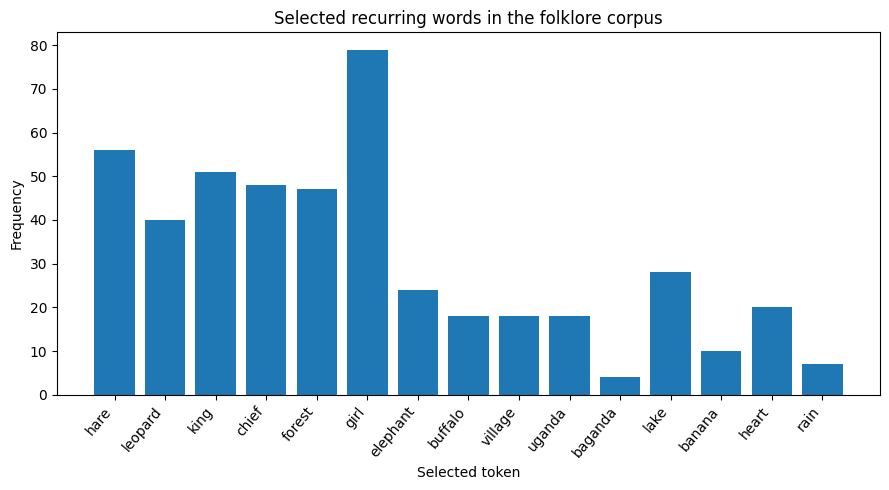

In [13]:
selected_terms = [
    "hare","leopard","king","chief","forest","girl","elephant",
    "buffalo","village","uganda","baganda","lake","banana","heart","rain"
]
selected_freq = {w: token_counts[w] for w in selected_terms}

plt.figure(figsize=(9, 5))
plt.bar(selected_freq.keys(), selected_freq.values())
plt.ylabel("Frequency")
plt.xlabel("Selected token")
plt.title("Selected recurring words in the folklore corpus")
plt.xticks(rotation=50, ha="right")
plt.tight_layout()
plt.show()

### Think before moving on

If a generated passage later contains words such as **hare**, **leopard**, **forest**, **king** or **buffalo**, does that prove that the LSTM understands Ugandan folklore?

**No.** It would show that the model has learned statistical regularities in this corpus. Recognising patterns is not the same as possessing human cultural understanding.

## 4. Train/validation/test split - by whole story

A serious evaluation must separate training information from final testing information.

If we randomly split overlapping word windows from the same story, almost identical passages could appear in both training and test sets. The test score would then look better than the model's ability to generalise to unseen narrative material.

So we split **whole stories** and require the three sets to be pairwise disjoint:

$$
\mathcal S_{\text{train}}\cap\mathcal S_{\text{val}}=\varnothing,\qquad
\mathcal S_{\text{train}}\cap\mathcal S_{\text{test}}=\varnothing,\qquad
\mathcal S_{\text{val}}\cap\mathcal S_{\text{test}}=\varnothing
$$

The split below is fixed so every student gets the same experiment.

In [14]:
TRAIN_TITLES = [
    "The River Fairy",
    "The Quits of Gomba",
    "The Cheats of Kijongo",
    "The Famine",
    "The Elephant That Wanted to Dance",
    "The Holy Man",
    "The Story of the Frog",
    "The Story of the Wonderful Goat",
    "The Dog and the Leopard",
    'The Law Concerning Fortune-Tellers; or, "The Wise Leper"',
    "The Lion-Girl",
    "The Man Who Knew Too Much",
    "The Buffalo Maiden",
    "The Story of Nsangi and the Apes",
    "The Mpa Bana Bird",
    "The Hare Who Earned a Cow and a Chieftainship",
]

VAL_TITLES = [
    "The Leopard, the Hare, and the Monkey",
    "Musoke the Moon-Boy",
]

TEST_TITLES = [
    "The Flame Tree",
    "The Absent-Minded Bridegroom",
    "The Royal Puff Adders of Budo",
]

assert set(TRAIN_TITLES).isdisjoint(VAL_TITLES)
assert set(TRAIN_TITLES).isdisjoint(TEST_TITLES)
assert set(VAL_TITLES).isdisjoint(TEST_TITLES)
assert set(TRAIN_TITLES + VAL_TITLES + TEST_TITLES) == set(STORIES)

split_table = pd.DataFrame(
    [(t, "Train") for t in TRAIN_TITLES] +
    [(t, "Validation") for t in VAL_TITLES] +
    [(t, "Test") for t in TEST_TITLES],
    columns=["Story", "Split"]
)
display(split_table)

,Story,Split
0,The River Fairy,Train
1,The Quits of Gomba,Train
2,The Cheats of Kijongo,Train
3,The Famine,Train
4,The Elephant That Wanted to Dance,Train
5,The Holy Man,Train
6,The Story of the Frog,Train
7,The Story of the Wonderful Goat,Train
8,The Dog and the Leopard,Train
9,"The Law Concerning Fortune-Tellers; or, ""The W...",Train


In [15]:
split_token_counts = {
    "Train": sum(len(tokenize(STORIES[t])) for t in TRAIN_TITLES),
    "Validation": sum(len(tokenize(STORIES[t])) for t in VAL_TITLES),
    "Test": sum(len(tokenize(STORIES[t])) for t in TEST_TITLES),
}
split_token_counts

{'Train': 17097, 'Validation': 3276, 'Test': 3328}

### Visualisation 6 - Number of tokens in each split

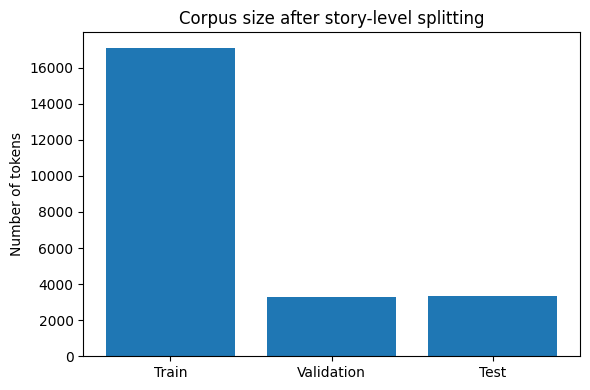

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(split_token_counts.keys(), split_token_counts.values())
plt.ylabel("Number of tokens")
plt.title("Corpus size after story-level splitting")
plt.tight_layout()
plt.show()

## 5. Vocabulary: token → ID

The model cannot use the string `"hare"` directly. We create a vocabulary:

$$
\text{token}\longrightarrow \text{integer ID}
$$

The integer is **only an index**. If `hare` has ID 83 and `king` has ID 20, that does **not** mean a hare is numerically larger than a king.

To avoid learning hundreds of extremely rare scan-specific forms, the vocabulary keeps training tokens that occur at least twice. Other tokens map to:

$$
\texttt{<UNK>}
$$

Importantly, the vocabulary is built from **training stories only**. We do not inspect validation/test text when deciding which tokens exist.

In [17]:
train_token_counts = Counter()
for title in TRAIN_TITLES:
    train_token_counts.update(tokenize(STORIES[title]))

MIN_FREQ = 2
itos = ["<UNK>"] + [tok for tok, count in train_token_counts.most_common() if count >= MIN_FREQ and tok != "<UNK>"]
stoi = {tok: idx for idx, tok in enumerate(itos)}

UNK_ID = stoi["<UNK>"]

print("Vocabulary size:", len(itos))
print("First 25 vocabulary entries:")
print(list(enumerate(itos[:25])))

Vocabulary size: 1029
First 25 vocabulary entries:
[(0, '<UNK>'), (1, 'the'), (2, ','), (3, 'and'), (4, '.'), (5, '"'), (6, 'a'), (7, 'to'), (8, 'he'), (9, 'was'), (10, 'in'), (11, 'of'), (12, 'her'), (13, 'she'), (14, 'they'), (15, 'i'), (16, 'you'), (17, 'it'), (18, 'for'), (19, 'that'), (20, 'said'), (21, 'but'), (22, 'his'), (23, 'had'), (24, 'is')]


In [18]:
demo_tokens = tokenize("The hare went into the forest.")
demo_ids = [stoi.get(tok, UNK_ID) for tok in demo_tokens]

demo_df = pd.DataFrame({"Token": demo_tokens, "ID": demo_ids})
display(demo_df)

,Token,ID
0,the,1
1,hare,72
2,went,48
3,into,62
4,the,1
5,forest,59
6,.,4


### Token ID versus embedding

A token ID identifies an entry. An **embedding** is a learned vector used for computation.

Let the integer ID at position $t$ be:

$$
\mathrm{id}_t = \text{token ID}
$$

The embedding layer looks up a vector:

$$
\mathbf e_t = E[\mathrm{id}_t]
$$

where $E$ is the learnable embedding matrix.

For example, an ID might be:

$$
83
$$

while its embedding may be:

$$
[0.14,\;-0.37,\;0.52,\;\ldots]
$$

The embedding is not a dictionary definition of the word. It is a numerical representation whose values are learned during training.

## 6. Turn stories into next-token training examples

Our task is **language modelling**:

> Given the previous $L$ tokens, predict the next token.

For sequence length $L=8$:

$$
P(w_{t+1}\mid w_{t-7},\ldots,w_t)
$$

Read that as:

> **What token is likely to come next, given the previous eight tokens?**

For a sequence such as:

`the little hare went into the forest and ...`

a training example might be:

**Input:** `the little hare went into the forest and`  
**Target:** the next token.

In [19]:
SEQ_LEN = 8

def make_windows(titles, seq_len=SEQ_LEN):
    xs, ys, target_known = [], [], []
    for title in titles:
        tokens = tokenize(STORIES[title])
        ids = [stoi.get(tok, UNK_ID) for tok in tokens]

        for i in range(len(ids) - seq_len):
            target_token = tokens[i + seq_len]
            xs.append(ids[i:i+seq_len])
            ys.append(ids[i+seq_len])
            target_known.append(target_token in stoi)

    return (
        torch.tensor(xs, dtype=torch.long),
        torch.tensor(ys, dtype=torch.long),
        torch.tensor(target_known, dtype=torch.bool),
    )

X_train, y_train, train_target_known = make_windows(TRAIN_TITLES)
X_val, y_val, val_target_known = make_windows(VAL_TITLES)
X_test, y_test, test_target_known = make_windows(TEST_TITLES)

print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))
print("Test examples:", len(X_test))
print("Input tensor shape:", tuple(X_train.shape))
print("Target tensor shape:", tuple(y_train.shape))
print(f"Validation OOV target rate: {100*(~val_target_known).float().mean().item():.1f}%")
print(f"Test OOV target rate:       {100*(~test_target_known).float().mean().item():.1f}%")

Training examples: 16969
Validation examples: 3260
Test examples: 3304
Input tensor shape: (16969, 8)
Target tensor shape: (16969,)
Validation OOV target rate: 10.5%
Test OOV target rate:       14.2%


In [20]:
def decode_ids(ids):
    return [itos[int(i)] for i in ids]

for i in [0, 50, 500]:
    print("Input :", " ".join(decode_ids(X_train[i])))
    print("Target:", itos[int(y_train[i])])
    print()

Input : a very long time ago a dreadful plague
Target: swept

Input : little girl , and she wandered away down
Target: the

Input : it has fields of soft green seaweed ,
Target: forests



### What kind of machine-learning problem is this?

- **One observation:** one sequence window of 8 previous tokens.
- **Input/features:** the ordered token sequence.
- **Target:** one next token.
- **Learning type:** supervised learning, because every training sequence has a known target.
- **Output type:** multiclass classification over the vocabulary.

Although we call it a language model, each training step is asking a classification-style question:

> **Which vocabulary item should come next?**

Because the vocabulary is learned from training stories only, some words in validation/test stories are genuinely unseen and map to `<UNK>`. We therefore report the **OOV (out-of-vocabulary) target rate** and calculate top-1/top-5 accuracy on targets that actually exist in the learned vocabulary. This avoids giving the model misleading credit for predicting “unknown” as though it had recovered the original unseen word.

## 7. First understand recurrence: what is a hidden state?

A conventional feed-forward network does not naturally carry a state from one position to the next. A recurrent neural network introduces a hidden state:

$$
\boxed{h_{t-1}}
\rightarrow
\boxed{\text{current recurrent calculation}}
\rightarrow
\boxed{h_t}
$$

A simplified RNN recurrence is:

$$
h_t=\tanh(W_xx_t+W_hh_{t-1}+b)
$$

where:

- $x_t$: current **numerical input vector** at position $t$; in our NLP pipeline this is the current token's embedding;
- $h_{t-1}$: previous hidden state;
- $h_t$: updated hidden state;
- $W_x,W_h,b$: learned parameters.

Do not read $h_t$ as a sentence stored in human language. It is a **numerical representation influenced by what the model has processed so far**.

### A tiny numerical recurrence - make memory visible

In [21]:
toy_x = np.array([1.0, 0.5, -1.0, 0.8])
toy_h = [0.0]

for x_t in toy_x:
    h_t = np.tanh(0.6 * x_t + 0.8 * toy_h[-1])
    toy_h.append(h_t)

toy_table = pd.DataFrame({
    "Step": np.arange(1, len(toy_x)+1),
    "x_t": toy_x,
    "h_t": toy_h[1:]
})
display(toy_table)

,Step,x_t,h_t
0,1,1.0,0.537050
1,2,0.5,0.622845
2,3,-1.0,-0.101375
3,4,0.8,0.379008


### Visualisation 7 - Hidden state changes as the sequence progresses

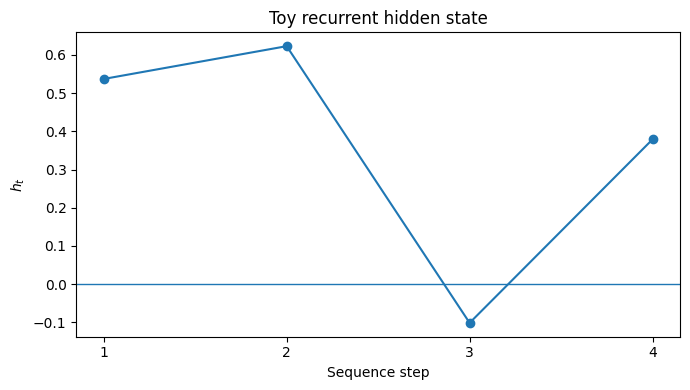

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(toy_x)+1), toy_h[1:], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Sequence step")
plt.ylabel("$h_t$")
plt.title("Toy recurrent hidden state")
plt.xticks(np.arange(1, len(toy_x)+1))
plt.tight_layout()
plt.show()

If we change an early input, a later hidden state can also change because each state depends on the previous one. That is the essential recurrent idea.

Real RNN hidden states are **vectors**, not one number, and the matrices are learned from data.

## 8. Why LSTMs?

Basic RNNs can struggle when useful information must survive across many sequence steps. During backpropagation through long sequences, gradients can become very small or very large. This contributes to the **vanishing-gradient** and **exploding-gradient** problems.

An LSTM introduces:

- a **hidden state** $h_t$;
- a **cell state** $c_t$;
- learned gates that control information flow.

At beginner level, the three gate ideas are the important part:

- **Forget gate:** how much old cell-state information should be retained?
- **Input gate:** how much new candidate information should be written?
- **Output gate:** how much of the current cell state should influence the hidden state?

These are learned numerical mechanisms. A programmer does **not** manually write rules such as “remember the word *king*.”

For speed and transparency, this practical trains on windows of only **8 tokens**. An LSTM can process longer sequences; the short window here is a teaching choice, not a definition of the architecture.

### LSTM equations - recognise the roles, do not memorise them

In these equations, $x_t$ means the current numerical input vector-here, the token embedding-not the integer token ID.

Forget gate:

$$
f_t=\sigma\left(W_f[h_{t-1},x_t]+b_f\right)
$$

Input gate:

$$
i_t=\sigma\left(W_i[h_{t-1},x_t]+b_i\right)
$$

Candidate cell content:

$$
\tilde{c}_t=\tanh\left(W_c[h_{t-1},x_t]+b_c\right)
$$

Updated cell state:

$$
c_t=f_t\odot c_{t-1}+i_t\odot\tilde{c}_t
$$

Output gate:

$$
o_t=\sigma\left(W_o[h_{t-1},x_t]+b_o\right)
$$

Updated hidden state:

$$
h_t=o_t\odot\tanh(c_t)
$$

The symbol $\odot$ means element-wise multiplication.

The conceptual summary is:

$$
\boxed{\text{retain some old information}}
+
\boxed{\text{write some new information}}
\rightarrow
\boxed{\text{updated cell state}}
\rightarrow
\boxed{\text{new hidden state}}
$$

### Visualisation 8 - Conceptual LSTM information flow

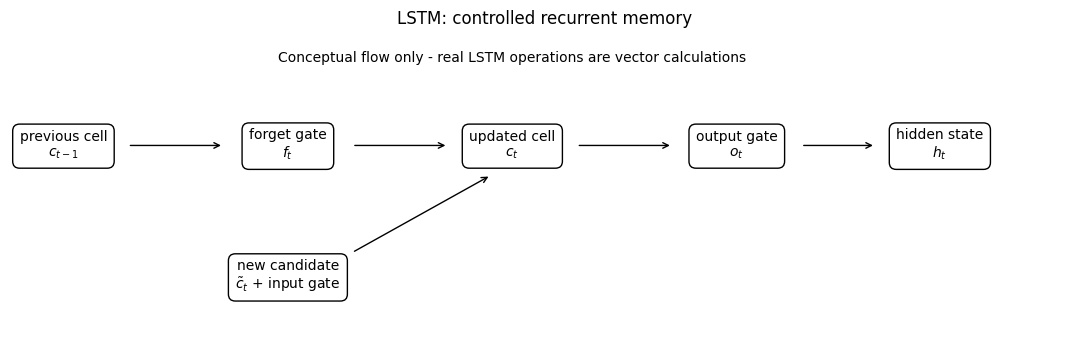

In [23]:
plt.figure(figsize=(11, 3.5))
plt.axis("off")

boxes = [
    (0.05, 0.62, "previous cell\n$c_{t-1}$"),
    (0.26, 0.62, "forget gate\n$f_t$"),
    (0.47, 0.62, "updated cell\n$c_t$"),
    (0.68, 0.62, "output gate\n$o_t$"),
    (0.87, 0.62, "hidden state\n$h_t$"),
    (0.26, 0.18, "new candidate\n$\\tilde{c}_t$ + input gate"),
]
for x, y, label in boxes:
    plt.text(x, y, label, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))

arrows = [
    ((0.11,0.62),(0.20,0.62)),
    ((0.32,0.62),(0.41,0.62)),
    ((0.53,0.62),(0.62,0.62)),
    ((0.74,0.62),(0.81,0.62)),
    ((0.32,0.26),(0.45,0.52)),
]
for a,b in arrows:
    plt.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle="->"))
plt.text(0.47, 0.90, "Conceptual flow only - real LSTM operations are vector calculations", ha="center")
plt.xlim(0,1)
plt.ylim(0,1)
plt.title("LSTM: controlled recurrent memory")
plt.tight_layout()
plt.show()

## 9. Build the complete LSTM language model

Our model is deliberately small:

$$
\text{Token IDs}
\rightarrow
\text{Embedding}
\rightarrow
\text{LSTM}
\rightarrow
\text{Linear layer}
\rightarrow
\text{Vocabulary logits}
$$

The final linear layer produces **one score for every vocabulary token**. Softmax can then convert those scores into probabilities.

In [24]:
EMBED_DIM = 48
HIDDEN_DIM = 96

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, return_details=False):
        embedded = self.embedding(x)
        sequence_output, (h_n, c_n) = self.lstm(embedded)
        final_hidden = sequence_output[:, -1, :]
        logits = self.output(final_hidden)

        if return_details:
            return logits, embedded, sequence_output, h_n, c_n
        return logits

torch.manual_seed(SEED)
model = LSTMLanguageModel(len(itos)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTrainable parameters: {trainable_params:,}")

LSTMLanguageModel(
  (embedding): Embedding(1029, 48)
  (lstm): LSTM(48, 96, batch_first=True)
  (output): Linear(in_features=96, out_features=1029, bias=True)
)

Trainable parameters: 205,269


### Visualisation 9 - Architecture at a glance

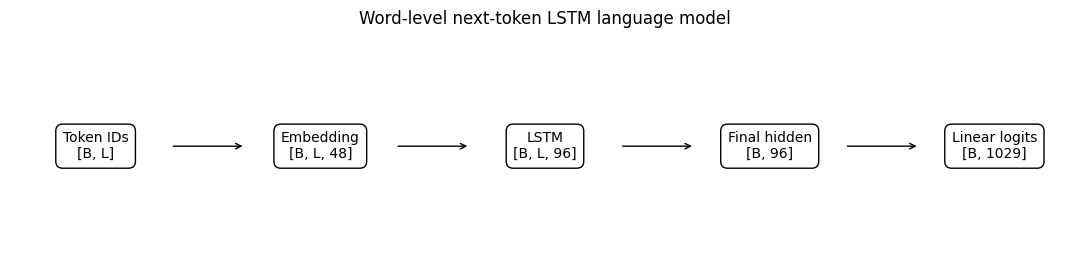

In [25]:
plt.figure(figsize=(11, 2.8))
plt.axis("off")
labels = [
    "Token IDs\n[B, L]",
    f"Embedding\n[B, L, {EMBED_DIM}]",
    f"LSTM\n[B, L, {HIDDEN_DIM}]",
    f"Final hidden\n[B, {HIDDEN_DIM}]",
    f"Linear logits\n[B, {len(itos)}]",
]
xs = np.linspace(0.08, 0.92, len(labels))
for x, label in zip(xs, labels):
    plt.text(x, 0.5, label, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))
for a,b in zip(xs[:-1], xs[1:]):
    plt.annotate("", xy=(b-0.07,0.5), xytext=(a+0.07,0.5),
                 arrowprops=dict(arrowstyle="->"))
plt.title("Word-level next-token LSTM language model")
plt.tight_layout()
plt.show()

## 10. Trace one example through the untrained network

In [26]:
example_x = X_train[0:1].to(device)
logits, embedded, seq_out, h_n, c_n = model(example_x, return_details=True)

print("Tokens:", decode_ids(example_x[0].cpu()))
print()
print("Input IDs:          ", tuple(example_x.shape))
print("Embedding output:   ", tuple(embedded.shape))
print("LSTM sequence out:  ", tuple(seq_out.shape))
print("Final h_n:          ", tuple(h_n.shape))
print("Final c_n:          ", tuple(c_n.shape))
print("Vocabulary logits:  ", tuple(logits.shape))

Tokens: ['a', 'very', 'long', 'time', 'ago', 'a', 'dreadful', 'plague']

Input IDs:           (1, 8)
Embedding output:    (1, 8, 48)
LSTM sequence out:   (1, 8, 96)
Final h_n:           (1, 1, 96)
Final c_n:           (1, 1, 96)
Vocabulary logits:   (1, 1029)


Read the shapes:

- $[B,L]$: batch size $B$, sequence length $L$;
- embedding adds an **embedding dimension**;
- the LSTM produces one hidden vector for **every sequence position**;
- $h_n$ and $c_n$ contain final recurrent states;
- logits contain one score for each vocabulary item.

### Important question

Is $h_n$ itself the predicted word?

**No.** It is an internal numerical representation. The final linear layer converts the representation into vocabulary scores.

## 11. Train the model

For each sequence, the model produces **logits**-raw scores for every vocabulary item. During training, cross-entropy encourages the correct next token to receive a higher probability.

For one target token, the idea can be written as:

$$
\mathcal L=-\log P_\theta\left(w_{t+1}\mid w_{t-L+1},\ldots,w_t\right)
$$

In PyTorch, `nn.CrossEntropyLoss` expects the **raw logits** and internally performs the required log-softmax calculation. We therefore do **not** apply softmax before passing the logits to this loss.

Training repeats:

$$
\boxed{\text{forward pass}}
\rightarrow
\boxed{\text{loss}}
\rightarrow
\boxed{\text{backpropagation}}
\rightarrow
\boxed{\text{parameter update}}
$$

We use Adam and clip gradients to reduce the effect of extremely large recurrent gradients.

In [61]:
BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

# Validation/test loaders also carry a mask telling us whether the original target
# token exists in the training vocabulary.
val_loader = DataLoader(
    TensorDataset(X_val, y_val, val_target_known),
    batch_size=256,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test, test_target_known),
    batch_size=256,
    shuffle=False,
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    n = 0
    known_n = 0
    top1_correct_known = 0
    top5_correct_known = 0

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                x, y, known = batch
            else:
                x, y = batch
                known = torch.ones_like(y, dtype=torch.bool)

            x, y, known = x.to(device), y.to(device), known.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * y.size(0)
            n += y.size(0)

            top1 = logits.argmax(dim=1)
            top5 = logits.topk(5, dim=1).indices

            known_n += known.sum().item()
            top1_correct_known += ((top1 == y) & known).sum().item()
            top5_correct_known += (
                (top5 == y.unsqueeze(1)).any(dim=1) & known
            ).sum().item()

    return {
        "loss": total_loss / n,
        "top1_known": top1_correct_known / max(1, known_n),
        "top5_known": top5_correct_known / max(1, known_n),
        "known_targets": known_n,
        "total_targets": n,
        "oov_rate": 1.0 - known_n / n,
    }

In [28]:
EPOCHS = 8
history = []
best_val_loss = float("inf")
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        n += y.size(0)

    train_loss = running_loss / n
    val_metrics = evaluate(val_loader)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_top1_known": val_metrics["top1_known"],
        "val_top5_known": val_metrics["top5_known"],
    }
    history.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:2d} | "
        f"train loss {train_loss:.3f} | "
        f"val loss {val_metrics['loss']:.3f} | "
        f"known-target top-1 {100*val_metrics['top1_known']:.1f}% | "
        f"top-5 {100*val_metrics['top5_known']:.1f}%"
    )

model.load_state_dict(best_state)
print(f"\nRestored the best validation-loss model from epoch {best_epoch}.")

Epoch  1 | train loss 5.417 | val loss 4.650 | known-target top-1 16.1% | top-5 32.2%
Epoch  2 | train loss 4.711 | val loss 4.379 | known-target top-1 18.2% | top-5 37.6%
Epoch  3 | train loss 4.320 | val loss 4.230 | known-target top-1 19.0% | top-5 40.5%
Epoch  4 | train loss 4.009 | val loss 4.133 | known-target top-1 18.6% | top-5 41.2%
Epoch  5 | train loss 3.750 | val loss 4.112 | known-target top-1 19.0% | top-5 42.4%
Epoch  6 | train loss 3.523 | val loss 4.100 | known-target top-1 19.6% | top-5 42.8%
Epoch  7 | train loss 3.315 | val loss 4.102 | known-target top-1 20.2% | top-5 43.0%
Epoch  8 | train loss 3.113 | val loss 4.127 | known-target top-1 20.5% | top-5 42.7%

Restored the best validation-loss model from epoch 6.


### Visualisation 10 - Training and validation loss

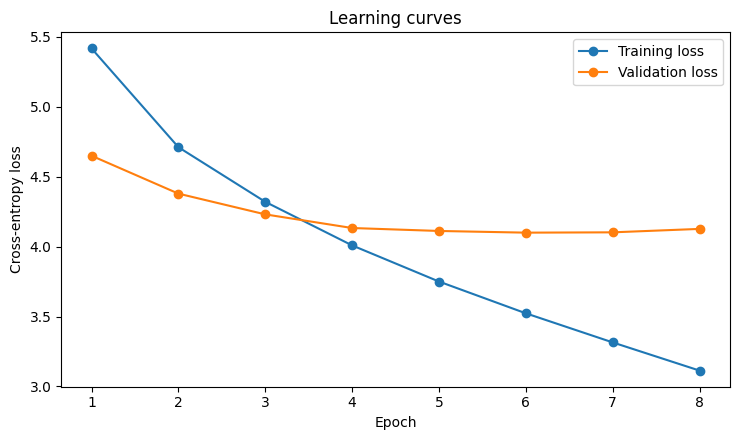

In [29]:
hist = pd.DataFrame(history)

plt.figure(figsize=(7.5, 4.5))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Training loss")
plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Learning curves")
plt.xticks(hist["epoch"])
plt.legend()
plt.tight_layout()
plt.show()

A falling training loss means the model is fitting the training examples better. Validation loss tells us whether that improvement transfers to **held-out stories**.

If training loss keeps falling while validation loss stops improving or rises, that is evidence consistent with **overfitting**.

The validation loss is calculated on the encoded validation set, including `<UNK>` where required. The accuracy plots below use only **known-vocabulary target tokens**, so an unseen original word is not counted as correctly recovered merely because it became `<UNK>`.

### Visualisation 11 - Validation top-1 and top-5 accuracy

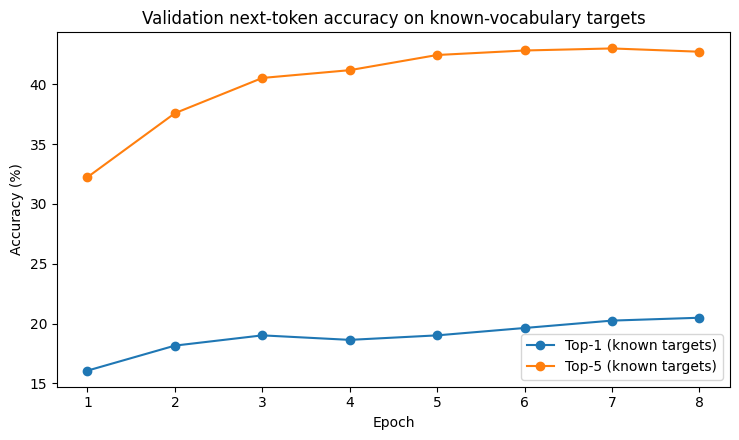

In [30]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(hist["epoch"], 100*hist["val_top1_known"], marker="o", label="Top-1 (known targets)")
plt.plot(hist["epoch"], 100*hist["val_top5_known"], marker="o", label="Top-5 (known targets)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation next-token accuracy on known-vocabulary targets")
plt.xticks(hist["epoch"])
plt.legend()
plt.tight_layout()
plt.show()

**Top-1 accuracy** asks whether the single highest-scoring token is exactly the observed next token.

**Top-5 accuracy** asks whether the observed next token appears anywhere among the model's five highest-scoring candidates.

Here we calculate both only when the original validation target is present in the training vocabulary. Natural language can have several plausible continuations, but top-5 still checks the **actual observed token**-it does not automatically treat every plausible alternative as correct.

## 12. Final test on stories held out from model fitting

In [31]:
test_metrics = evaluate(test_loader)

print("Held-out test stories:")
for t in TEST_TITLES:
    print(" -", t)

# Simple baseline: always predict the most common encoded training target.
most_common_target_id, _ = Counter(y_train.tolist()).most_common(1)[0]
baseline_token = itos[most_common_target_id]
known_mask = test_target_known
baseline_correct = ((y_test == most_common_target_id) & known_mask).sum().item()
baseline_acc = baseline_correct / max(1, known_mask.sum().item())

print(f"\nEncoded test loss:          {test_metrics['loss']:.3f}")
print(f"Test OOV target rate:       {100*test_metrics['oov_rate']:.1f}%")
print(f"Known-target test top-1:    {100*test_metrics['top1_known']:.1f}%")
print(f"Known-target test top-5:    {100*test_metrics['top5_known']:.1f}%")
print(f"Most-common-token baseline: {100*baseline_acc:.1f}%  (always predicts '{baseline_token}')")

Held-out test stories:
 - The Flame Tree
 - The Absent-Minded Bridegroom
 - The Royal Puff Adders of Budo

Encoded test loss:          4.297
Test OOV target rate:       14.2%
Known-target test top-1:    17.4%
Known-target test top-5:    39.1%
Most-common-token baseline: 8.3%  (always predicts 'the')


Do **not** compare these numbers directly with modern large language models. This is a tiny word-level LSTM trained from scratch on a small historical corpus.

The OOV rate tells us how often the true next token in the held-out stories did not exist in the training vocabulary. For those cases, the model cannot recover the original word exactly.

The simple baseline always predicts the most frequent training target. A useful model should provide evidence that it is learning **context-dependent sequence structure**, not merely repeating the most common token.

## 13. Inspect learned embeddings

During training, the embedding matrix was updated together with the LSTM.

We can inspect selected words, but be careful:

> Similar-looking vectors do **not** prove that the model has learned human semantic definitions.

They simply show numerical representations learned for this prediction task.

In [32]:
embedding_words = [
    w for w in ["hare","leopard","king","chief","forest","girl",
                "elephant","buffalo","village","rain","lake","heart"]
    if w in stoi
]

embedding_matrix = model.embedding.weight.detach().cpu().numpy()
selected_vectors = np.vstack([embedding_matrix[stoi[w]] for w in embedding_words])

print("Words shown:", embedding_words)
print("Selected embedding matrix shape:", selected_vectors.shape)

Words shown: ['hare', 'leopard', 'king', 'chief', 'forest', 'girl', 'elephant', 'buffalo', 'village', 'rain', 'lake', 'heart']
Selected embedding matrix shape: (12, 48)


### Visualisation 12 - Embedding heatmap

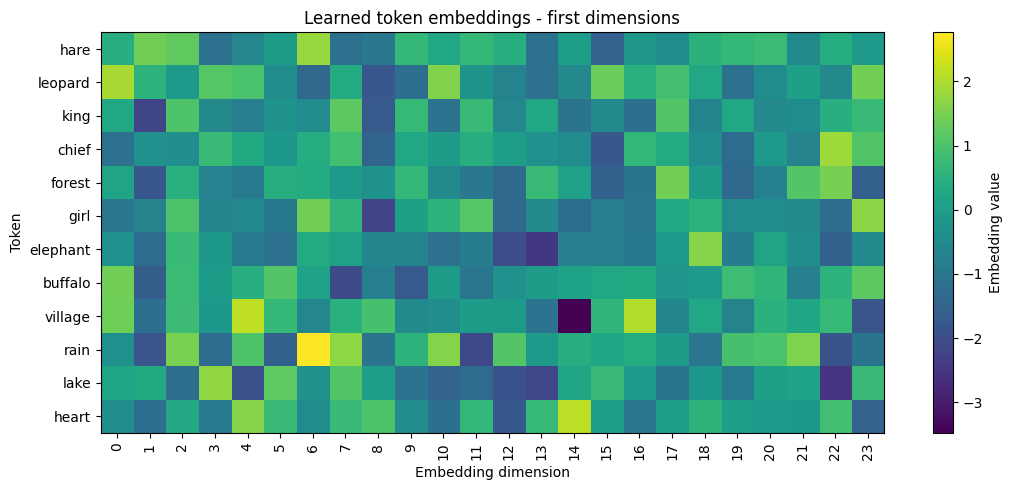

In [33]:
dims_to_show = min(24, EMBED_DIM)
plt.figure(figsize=(11, 5))
plt.imshow(selected_vectors[:, :dims_to_show], aspect="auto")
plt.colorbar(label="Embedding value")
plt.yticks(np.arange(len(embedding_words)), embedding_words)
plt.xticks(np.arange(dims_to_show), np.arange(dims_to_show), rotation=90)
plt.xlabel("Embedding dimension")
plt.ylabel("Token")
plt.title("Learned token embeddings - first dimensions")
plt.tight_layout()
plt.show()

### Visualisation 13 - A 2D view of selected embeddings

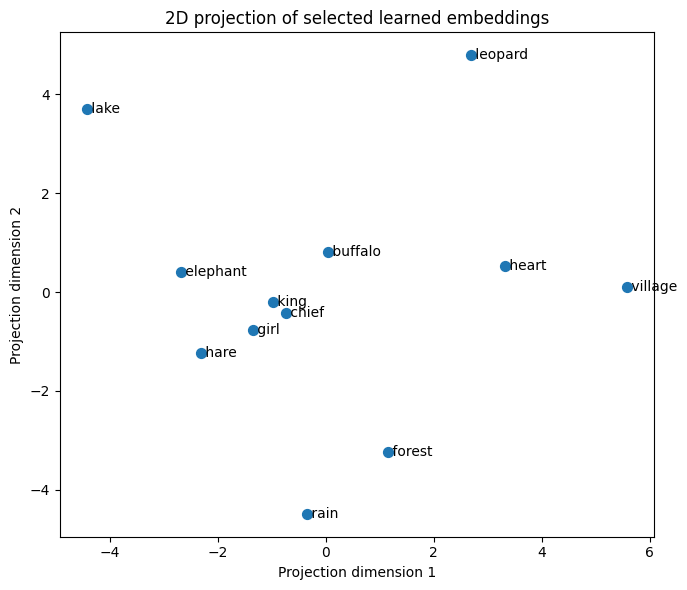

In [34]:
# Mean-centre selected vectors, then project using SVD.
centred = selected_vectors - selected_vectors.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(centred, full_matrices=False)
coords = centred @ Vt[:2].T

plt.figure(figsize=(7, 6))
plt.scatter(coords[:,0], coords[:,1], s=50)
for word, (x, y) in zip(embedding_words, coords):
    plt.text(x, y, " " + word, va="center")
plt.xlabel("Projection dimension 1")
plt.ylabel("Projection dimension 2")
plt.title("2D projection of selected learned embeddings")
plt.tight_layout()
plt.show()

This projection compresses a much higher-dimensional space into two dimensions, so apparent distance in this plot should be interpreted cautiously. It is a visual aid, not proof of semantic categories.

## 14. Watch hidden states change across real text

The LSTM produces one hidden vector at every sequence position.

We will take the opening tokens from one **training story** and visualise selected hidden dimensions. The heatmap does **not** assign human meanings to individual dimensions. It only demonstrates that the model's internal state evolves as new context arrives.

In [35]:
inspect_title = "The Dog and the Leopard"
inspect_tokens = tokenize(STORIES[inspect_title])[:14]
inspect_ids = torch.tensor([[stoi.get(tok, UNK_ID) for tok in inspect_tokens]], dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    embedded = model.embedding(inspect_ids)
    hidden_sequence, (h_last, c_last) = model.lstm(embedded)

hidden_np = hidden_sequence[0].cpu().numpy()
print("Tokens:", inspect_tokens)
print("Hidden sequence shape:", hidden_np.shape)

Tokens: ['once', 'upon', 'a', 'time', 'a', 'leopard', 'who', 'had', 'several', 'cubs', 'hired', 'a', 'dog', 'to']
Hidden sequence shape: (14, 96)


### Visualisation 14 - Hidden-state heatmap

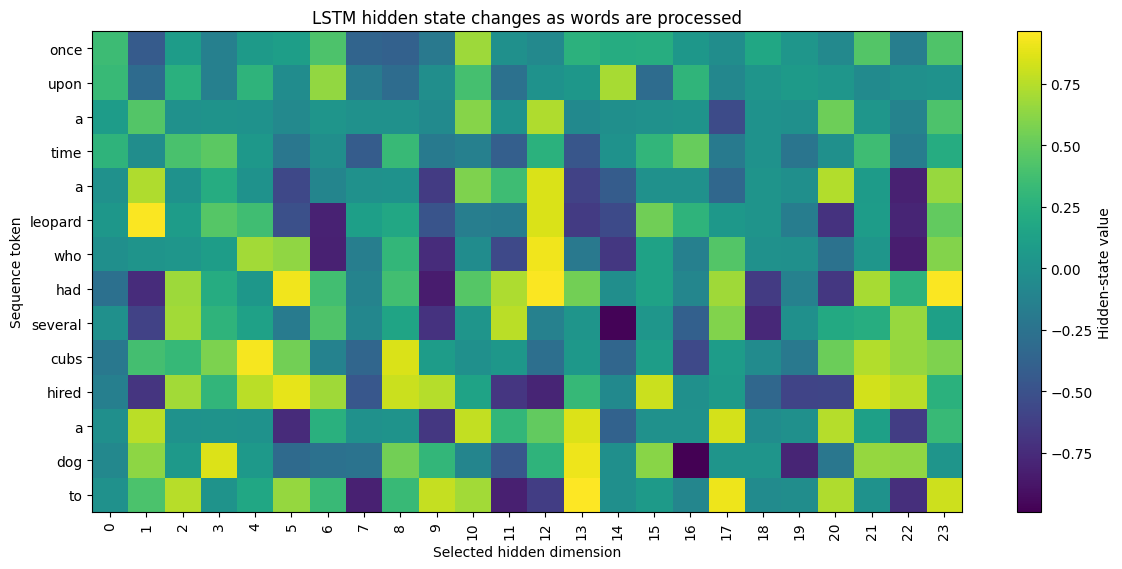

In [36]:
hidden_dims = min(24, HIDDEN_DIM)
plt.figure(figsize=(12, 5.8))
plt.imshow(hidden_np[:, :hidden_dims], aspect="auto")
plt.colorbar(label="Hidden-state value")
plt.yticks(np.arange(len(inspect_tokens)), inspect_tokens)
plt.xticks(np.arange(hidden_dims), np.arange(hidden_dims), rotation=90)
plt.xlabel("Selected hidden dimension")
plt.ylabel("Sequence token")
plt.title("LSTM hidden state changes as words are processed")
plt.tight_layout()
plt.show()

Notice that even common words can produce different hidden states depending on what came before them.

A useful conceptual statement is:

> $h_t$ is a learned numerical summary influenced by the sequence seen up to position $t$.

It is **not** correct to say that one hidden dimension literally means “leopard” or “king” unless we perform additional analysis that supports that claim.

## 15. Next-token prediction - inspect the probabilities

In [37]:
def next_token_distribution(prompt, temperature=1.0):
    tokens = tokenize(prompt)
    if not tokens:
        raise ValueError("Prompt must contain at least one token.")

    ids = [stoi.get(tok, UNK_ID) for tok in tokens[-SEQ_LEN:]]
    x = torch.tensor([ids], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)[0].clone()

    # We do not want to generate the special unknown token.
    logits[UNK_ID] = -1e9
    probs = F.softmax(logits / temperature, dim=0)
    return tokens, probs.cpu()

def top_predictions(prompt, k=10, temperature=1.0):
    tokens, probs = next_token_distribution(prompt, temperature)
    values, indices = torch.topk(probs, k)
    return pd.DataFrame({
        "token": [itos[int(i)] for i in indices],
        "probability": values.numpy()
    })

prompt = "the little girl went to the forest"
pred_df = top_predictions(prompt, k=10)
print("Prompt:", prompt)
display(pred_df)

Prompt: the little girl went to the forest


,token,probability
0,",",0.282524
1,and,0.171937
2,.,0.122821
3,to,0.063077
4,with,0.028726
5,in,0.023290
6,who,0.020702
7,:,0.012657
8,;,0.010753
9,path,0.010232


### Visualisation 15 - The model predicts a distribution, not just one word

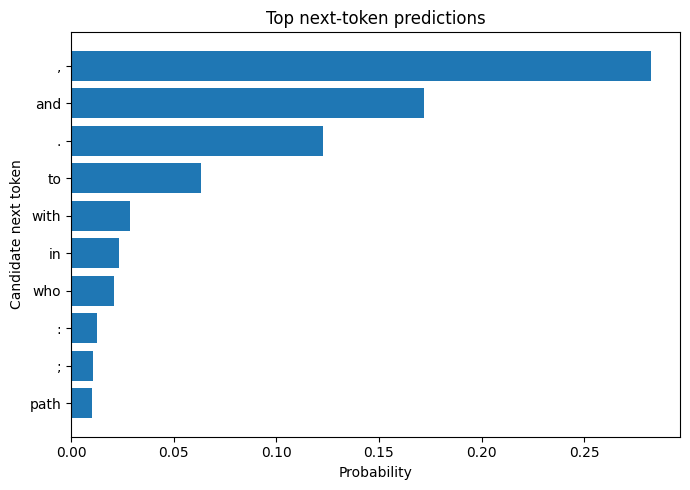

In [38]:
plot_df = pred_df.sort_values("probability", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(plot_df["token"], plot_df["probability"])
plt.xlabel("Probability")
plt.ylabel("Candidate next token")
plt.title("Top next-token predictions")
plt.tight_layout()
plt.show()

The model does not internally store a single sentence completion. It produces scores for the entire vocabulary.

Softmax converts logits $z_i$ into probabilities:

$$
P(w_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

The highest probability is one possible choice, but generation can also **sample** from the distribution.

## 16. Generation = repeated next-token prediction

Generation is an iterative process:

1. give the model a prompt;
2. predict a probability distribution for the next token;
3. choose or sample one token;
4. append it to the sequence;
5. feed the extended context back into the model;
6. repeat.

Conceptually:

$$
w_{t+1}\sim P(w\mid w_{\le t})
$$

then:

$$
(w_1,\ldots,w_t)
\rightarrow
(w_1,\ldots,w_t,w_{t+1})
$$

and the process continues.

For classroom stability, the generator below uses **top-$k$ sampling** with $k=20$: at each step we keep only the 20 highest-scoring candidate tokens and sample among them. This prevents extremely unlikely vocabulary items from dominating a short demonstration. When we compare temperatures later, $k$ stays fixed so that temperature is the main factor being changed.

**Important:** this teaching model was trained on fixed windows of 8 tokens. During generation, each next-token prediction therefore recomputes the LSTM state from the **latest 8 tokens**. It does not carry one hidden state indefinitely through the whole generated passage.

In [39]:
def detokenize(tokens):
    """Convert our simple word-level tokens back into readable text."""
    text = ""
    quote_open = False
    closing = {".", ",", "!", "?", ";", ":", ")"}

    for tok in tokens:
        if tok == '"':
            if quote_open:              # closing quote
                text = text.rstrip() + '"'
                quote_open = False
            else:                       # opening quote
                if text and not text.endswith((" ", "(", "-")):
                    text += " "
                text += '"'
                quote_open = True

        elif tok in closing:
            text = text.rstrip() + tok + " "

        elif tok == "(":
            if text and not text.endswith(" "):
                text += " "
            text += "("

        elif tok == "-":
            text = text.rstrip() + " - "

        elif tok == "-":
            text = text.rstrip() + "-"

        else:
            # No space immediately after an opening quote or hyphen.
            if text and not text.endswith((" ", '"', "(", "-", "-")):
                text += " "
            text += tok

    text = re.sub(r'"{2,}', '"', text)  # collapse accidental repeated quote tokens
    text = re.sub(r'([.!?,;:])"(?=[A-Za-z])', r'\1" ', text)
    return re.sub(r"\s+", " ", text).strip()

def generate_text(prompt, new_tokens=70, temperature=0.8, top_k=20, seed=123):
    if temperature <= 0:
        raise ValueError("temperature must be greater than 0")
    if top_k < 1:
        raise ValueError("top_k must be at least 1")

    generator = torch.Generator().manual_seed(seed)
    output_tokens = tokenize(prompt)

    if not output_tokens:
        raise ValueError("Prompt must contain at least one token.")

    model.eval()

    for _ in range(new_tokens):
        context = output_tokens[-SEQ_LEN:]
        ids = [stoi.get(tok, UNK_ID) for tok in context]
        x = torch.tensor([ids], dtype=torch.long).to(device)

        with torch.no_grad():
            logits = model(x)[0].clone()

        # Do not generate the special unknown token.
        logits[UNK_ID] = -1e9
        scaled = logits / temperature

        k = min(top_k, len(itos) - 1)
        values, indices = torch.topk(scaled, k=k)
        probs = F.softmax(values, dim=0)

        chosen_in_topk = torch.multinomial(probs.cpu(), 1, generator=generator).item()
        next_id = int(indices[chosen_in_topk].cpu())
        output_tokens.append(itos[next_id])

    return detokenize(output_tokens)

demo_prompt = "once upon a time"
print(generate_text(demo_prompt, new_tokens=90, temperature=0.7, top_k=20, seed=7))

once upon a time sunset at last the man was the frog and he was a cave, and the girl were in a great fish. "the hare was quite down and had seen the girl and the witchdoctor, and the girl gave down the forest, and they built a great reward and his gourd." i have seen your friend. "then he was very unhappy and the old granny had not a small, and he did not play the river fairy." then he


The output will not read like a professionally written story. That is useful evidence.

This model has:
- only a small historical corpus;
- a small word-level vocabulary;
- one LSTM layer;
- short context windows;
- no explicit beginning/end-of-story tokens;
- no external knowledge;
- no transformer attention;
- no instruction tuning.

Generation therefore stops because **we request a fixed number of new tokens**, not because the model has learned a special end-of-story signal.

Yet you should begin to notice **recurring vocabulary, narrative constructions, characters/animals and dialogue-like patterns** from the training collection.

## 17. Temperature - control how concentrated the sampling distribution is

Temperature rescales logits before softmax:

$$
P_T(w_i)
=
\frac{\exp(z_i/T)}
{\sum_j \exp(z_j/T)}
$$

- $T<1$: distribution becomes sharper; high-probability choices dominate.
- $T\approx1$: ordinary sampling distribution.
- $T>1$: distribution becomes flatter; lower-ranked choices become more likely.

Temperature does **not** retrain the model. It changes the distribution used for sampling.

The probability plots below show the model distribution after temperature scaling. During the generated-text comparison, **top-$k$ remains fixed at 20**, so we are not quietly changing two generation settings at once.

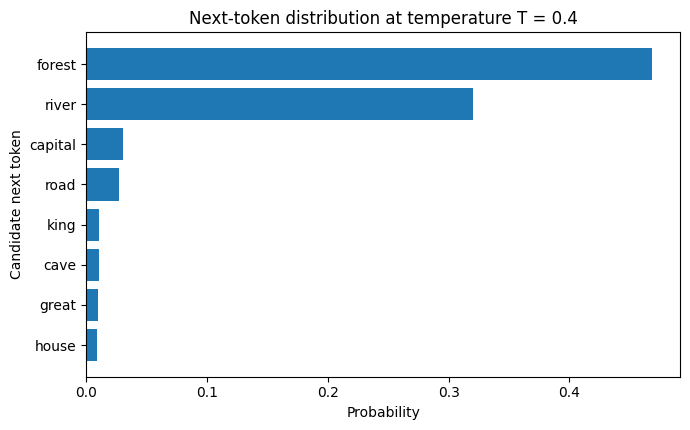

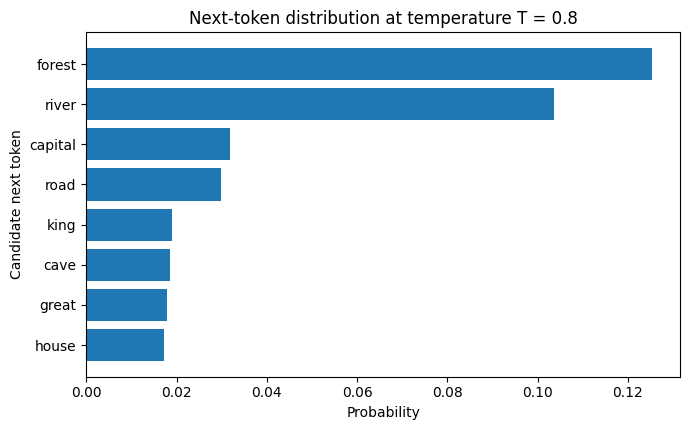

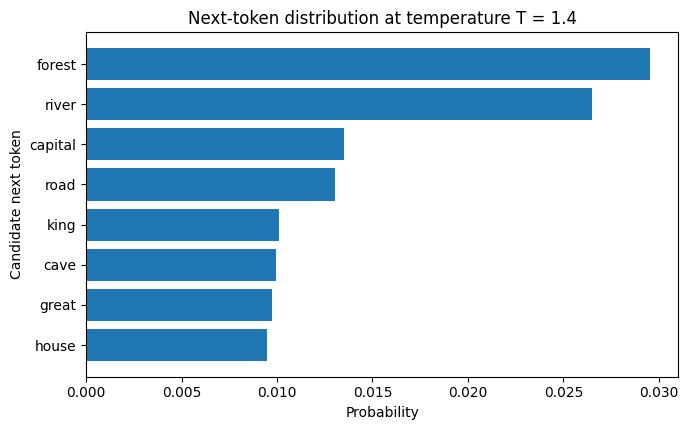

In [40]:
temperature_prompt = "the hare went to the"
temperatures = [0.4, 0.8, 1.4]

for T in temperatures:
    df = top_predictions(temperature_prompt, k=8, temperature=T).sort_values("probability")
    plt.figure(figsize=(7, 4.4))
    plt.barh(df["token"], df["probability"])
    plt.xlabel("Probability")
    plt.ylabel("Candidate next token")
    plt.title(f"Next-token distribution at temperature T = {T}")
    plt.tight_layout()
    plt.show()

### Compare generated text at different temperatures

In [41]:
for T in [0.4, 0.8, 1.4]:
    print("=" * 80)
    print(f"TEMPERATURE = {T}")
    print(generate_text("once upon a time", new_tokens=70, temperature=T, seed=21))
    print()

TEMPERATURE = 0.4
once upon a time she was a great feast and the dog was sorry in the forest, and the old granny was so frightened that he had a little girl, and the girl was sitting, and the mother said, "i will be a cave, and the owl had been the forest, and the young elephant was a little girl." the woman had been bewitched.

TEMPERATURE = 0.8
once upon a time she was a whole cave, and as the king of the leopard of his little white flowers. "it in a cow, mpa bana, and the girl saw very much and he told him with thick him; but the chief had been. her fortune are." now the girl would see to the capital and told the river; but he looked down

TEMPERATURE = 1.4
once upon a time she thought at it were she was afraid and was very hungry when the hare was much and ran away the great lake shells and a great feast. "what has not happened." but the hares sat in it. but the lion - man did not see that a basket of food he thought very good of your hut, and a little girl they were



Typical pattern:

- very low temperature can become repetitive or overly predictable;
- moderate temperature often balances structure and variety;
- high temperature can increase novelty but also grammatical or narrative breakdown.

There is no universal “best” temperature. The useful value depends on the task and the desired behaviour.

## 18. Compare generated vocabulary with the source corpus

In [42]:
generated_sample = generate_text(
    "once upon a time",
    new_tokens=300,
    temperature=0.8,
    top_k=20,
    seed=99
)
generated_counts = Counter(tokenize(generated_sample))

train_source_tokens = []
for title in TRAIN_TITLES:
    train_source_tokens.extend(tokenize(STORIES[title]))
train_source_counts = Counter(train_source_tokens)

comparison_terms = ["hare","leopard","king","chief","forest","girl","elephant","buffalo","village","rain"]
compare_df = pd.DataFrame({
    "token": comparison_terms,
    "training_per_1000": [
        1000 * train_source_counts[w] / len(train_source_tokens) for w in comparison_terms
    ],
    "generated_per_1000": [
        1000 * generated_counts[w] / max(1, sum(generated_counts.values())) for w in comparison_terms
    ],
})
display(compare_df)

,token,training_per_1000,generated_per_1000
0,hare,2.222612,6.578947
1,leopard,1.169796,0.000000
2,king,1.462245,3.289474
3,chief,1.637714,6.578947
4,forest,2.573551,16.447368
5,girl,3.567877,3.289474
6,elephant,1.403755,6.578947
7,buffalo,1.052816,0.000000
8,village,0.760367,0.000000
9,rain,0.233959,0.000000


### Visualisation 16 - Source versus generated token frequencies

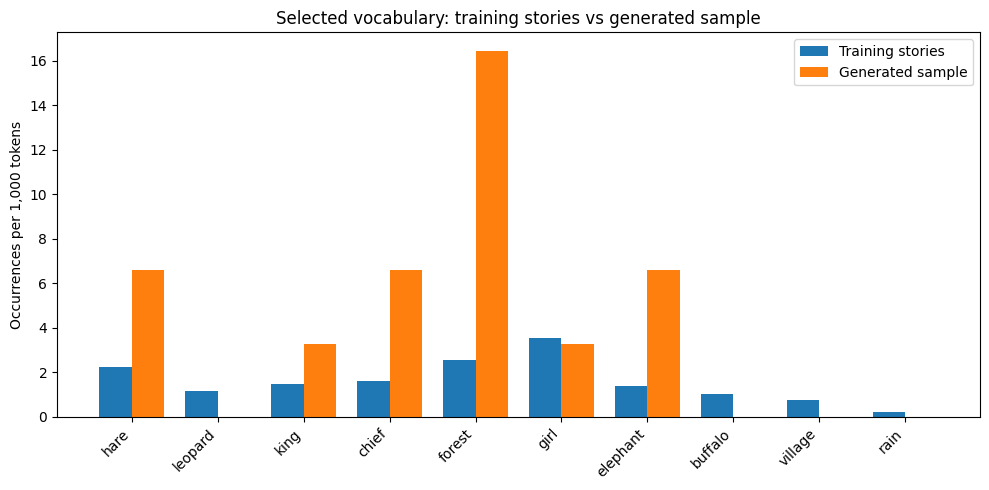

In [43]:
x = np.arange(len(compare_df))
width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, compare_df["training_per_1000"], width, label="Training stories")
plt.bar(x + width/2, compare_df["generated_per_1000"], width, label="Generated sample")
plt.xticks(x, compare_df["token"], rotation=45, ha="right")
plt.ylabel("Occurrences per 1,000 tokens")
plt.title("Selected vocabulary: training stories vs generated sample")
plt.legend()
plt.tight_layout()
plt.show()

Do not expect the two distributions to match exactly. We generated only one small sample, and sampling contains randomness. The purpose is to ask whether the model output visibly reflects some statistics of the **stories it was actually trained on**.

## 19. One deliberate failure test

In [44]:
unusual_prompt = "quantum computers danced beside the lake"
unusual_tokens = tokenize(unusual_prompt)
encoded_for_model = [tok if tok in stoi else "<UNK>" for tok in unusual_tokens]

display(pd.DataFrame({
    "Prompt token": unusual_tokens,
    "What the model receives": encoded_for_model,
}))

print("\nGenerated continuation:")
print(generate_text(unusual_prompt, new_tokens=65, temperature=0.8, top_k=20, seed=11))

,Prompt token,What the model receives
0,quantum,<UNK>
1,computers,<UNK>
2,danced,danced
3,beside,<UNK>
4,the,the
5,lake,lake



Generated continuation:
quantum computers danced beside the lake city. when the other women on the water, and he had a little way, and the chief said to the river fairy. the young elephant were one a great lake city and the road have a cave, and she was very hungry they could come in the forest. he is the big grey elephant called. "the king


### What should you notice?

Words outside the training vocabulary become `<UNK>` internally. The model then tries to continue using patterns it **does** know.

This exposes several limitations:

- the model is bounded by its training corpus;
- it has no reliable factual grounding;
- fluent-looking text is not evidence of truth;
- generated language can combine familiar patterns in nonsensical ways.

This is one reason **human-like output should not be confused with human-like understanding**.

## 20. Complete pipeline - be able to explain every arrow

$$
\boxed{\text{Ugandan folklore stories}}
\rightarrow
\boxed{\text{tokenisation}}
\rightarrow
\boxed{\text{vocabulary IDs}}
\rightarrow
\boxed{\text{embeddings}}
\rightarrow
\boxed{\text{LSTM sequence processing}}
$$

$$
\rightarrow
\boxed{h_t,\ c_t}
\rightarrow
\boxed{\text{vocabulary logits}}
\rightarrow
\boxed{\text{softmax probabilities}}
\rightarrow
\boxed{\text{next token}}
$$

$$
\boxed{\text{repeat next-token prediction}}
\rightarrow
\boxed{\text{generated text}}
$$

If you can explain why every transformation is needed, you understand the main purpose of this practical.

# STUDENT TODO SUBMISSION

Complete the following tasks **in this notebook**. Your answers should use outputs, tables or visualisations as evidence.

Do not simply say “the model improved” or “the hidden state changed.” Show the result and explain what the result means.

## TODO 1 - Explore one story

Choose **one story that was not used in the earlier corpus demonstration**.

Report:

1. story title;
2. approximate word/token count;
3. five distinctive non-stopword tokens and their frequencies;
4. one short explanation of **why order matters** in this text.

Create a bar chart for your five selected tokens.

In [65]:
# TODO 1 - YOUR CODE HERE
# Suggested start:
# chosen_title = ...
# chosen_tokens = tokenize(STORIES[chosen_title])
# ...


Story title: The Flame Tree
Approximate word count: 1079
Token count: 1220

Five distinctive non-stopword tokens:


,Token,Frequency
0,maiden,11
1,lake,11
2,peasant,10
3,boy,10
4,tutu,9


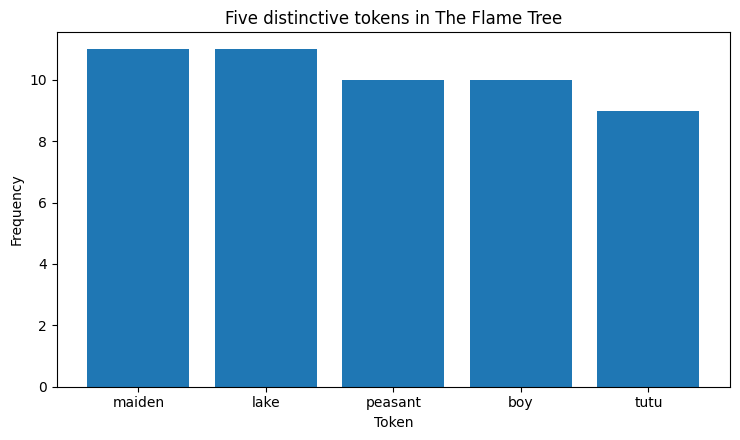

In [69]:
# TODO 1 - Explore one story
# We choose a held-out TEST story that was not used in the earlier instructor demonstration.
chosen_title = "The Flame Tree"
chosen_text = STORIES[chosen_title]
chosen_tokens = tokenize(chosen_text)

# "Word count" is based on whitespace-separated words; "token count" is based on our NLP tokenizer.
word_count = len(chosen_text.split())
token_count = len(chosen_tokens)

# Remove common stopwords and punctuation for exploration only.
chosen_content_counts = Counter(
    tok for tok in chosen_tokens
    if tok not in STOPWORDS and len(tok) > 2 and tok.isalpha()
)
top_five_tokens = chosen_content_counts.most_common(5)
todo1_df = pd.DataFrame(top_five_tokens, columns=["Token", "Frequency"])

print("Story title:", chosen_title)
print("Approximate word count:", word_count)
print("Token count:", token_count)
print("\nFive distinctive non-stopword tokens:")
display(todo1_df)

plt.figure(figsize=(7.5, 4.5))
plt.bar(todo1_df["Token"], todo1_df["Frequency"])
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title(f"Five distinctive tokens in {chosen_title}")
plt.tight_layout()
plt.show()


### TODO 1 explanation

**Story selected:** *The Flame Tree*. It is one of the final test stories, so it was not used for model fitting.

The story contains approximately **1,079 whitespace-separated words** and **1,220 tokens** under the notebook's tokenizer. The five selected non-stopword tokens are **maiden (11), lake (11), peasant (10), boy (10), and tutu (9)**.

**Why order matters:** language is sequential because the meaning and prediction of a token depend on the tokens that came before it. For example, changing the order of words in a sentence can change its meaning and can also change which next token is likely. An LSTM uses this ordered context when producing its hidden state and predicting the next token.


## TODO 2 - Tokens, IDs and embeddings

Choose one sentence of at least **8 tokens** from your selected story.

Show:

$$
\text{text}\rightarrow\text{tokens}\rightarrow\text{token IDs}
$$

Then display the embedding vector for **one token** from your sentence.

Prefer a token that exists in `stoi`. If you deliberately choose an out-of-vocabulary token, state clearly that the model receives `<UNK>` and therefore uses the `<UNK>` embedding rather than a unique embedding for that original word.

In a Markdown cell, explain the difference between:

- token;
- token ID;
- embedding.

Do not say that the numerical ID itself contains the word's meaning.

In [70]:
# TODO 2 - YOUR CODE HERE
# sentence = ...
# tokens = ...
# ids = ...
# embedding = ...

In [71]:
# TODO 2 - Tokens, IDs and embeddings
sentence = "The Maiden was very sad when she said good-bye to Tutu."
tokens = tokenize(sentence)
ids = [stoi.get(tok, UNK_ID) for tok in tokens]

todo2_df = pd.DataFrame({
    "Token": tokens,
    "Token_ID": ids,
    "Known_in_vocabulary": [tok in stoi for tok in tokens],
})
display(todo2_df)

# Show one learned embedding vector. "maiden" is in the vocabulary.
embedding_token = "maiden"
embedding_id = stoi[embedding_token]

model.eval()
with torch.no_grad():
    embedding_vector = model.embedding(
        torch.tensor([embedding_id], dtype=torch.long, device=device)
    )[0].cpu().numpy()

print(f"Selected token: {embedding_token!r}")
print(f"Token ID: {embedding_id}")
print(f"Embedding shape: {embedding_vector.shape}")
print("Embedding vector:")
print(np.round(embedding_vector, 4))


,Token,Token_ID,Known_in_vocabulary
0,the,1,True
1,maiden,245,True
2,was,9,True
3,very,32,True
4,sad,663,True
5,when,30,True
6,she,13,True
7,said,20,True
8,good,105,True
9,-,47,True


Selected token: 'maiden'
Token ID: 245
Embedding shape: (48,)
Embedding vector:
[ 0.2963  1.1199 -1.2102 -1.4763  1.2166 -1.9983 -0.3972 -1.7436 -0.4627
  0.2528  0.9082 -0.1393 -1.5428 -0.3242 -1.6671  0.2748 -0.1552 -1.082
 -0.2854  0.1903  0.6324 -0.1011  0.748   0.6846 -0.252   0.5776  1.6043
 -0.5439 -2.5054 -0.0031  0.2782  0.0885 -0.3741  1.9704  2.0543  1.5871
  1.0337  1.4474  0.5345  0.0159 -0.6152  1.5759  0.3467  0.301   1.1751
 -0.688   0.5722  0.9881]


### TODO 2 explanation

- **Token:** a unit produced by the tokenizer, such as `maiden`, `was`, or `.`.
- **Token ID:** the integer index assigned to that token in the model vocabulary. It is an identifier only; the number itself does not contain the word's meaning.
- **Embedding:** a learned numerical vector associated with a token ID. Here the embedding has **48 dimensions**.

In this sentence, `tutu` is not in the learned vocabulary because the vocabulary was built from the training stories with `MIN_FREQ = 2`. Therefore, its ID is the `<UNK>` ID. The model uses the shared `<UNK>` embedding for that token rather than a unique embedding for `tutu`.


## TODO 3 - Hidden-state investigation

Use a sentence different from the instructor demonstration.

1. pass its tokens through the trained embedding + LSTM;
2. display the hidden-state tensor shape;
3. create a heatmap for at least 16 hidden dimensions;
4. explain why the hidden state changes from token to token.

Your explanation must include the term **context**.

In [47]:
# TODO 3 - YOUR CODE HERE

Sentence: The army marched down to the Lake shore to fight the Islanders who came across the blue waters in a fleet of war canoes.
Tokens: ['the', 'army', 'marched', 'down', 'to', 'the', 'lake', 'shore', 'to', 'fight', 'the', 'islanders', 'who', 'came', 'across', 'the', 'blue', 'waters', 'in', 'a', 'fleet', 'of', 'war', 'canoes', '.']
Hidden-state tensor shape: (1, 25, 96)
Final hidden-state shape: (1, 1, 96)
Final cell-state shape: (1, 1, 96)


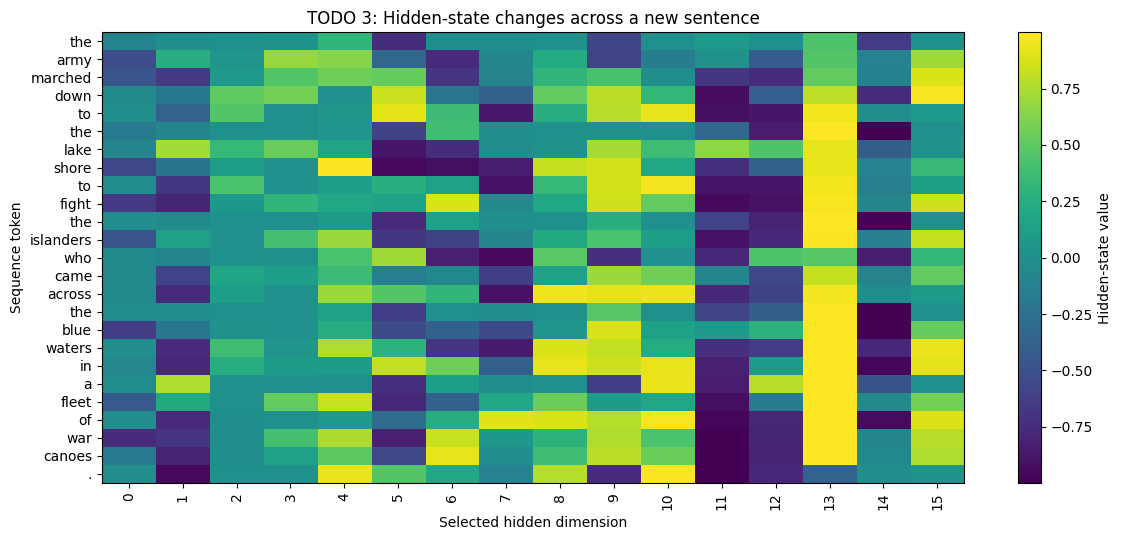

In [72]:
# TODO 3 - Hidden-state investigation
# This is different from the instructor's earlier hidden-state demonstration.
hidden_sentence = (
    "The army marched down to the Lake shore to fight the Islanders "
    "who came across the blue waters in a fleet of war canoes."
)
hidden_tokens = tokenize(hidden_sentence)
hidden_ids = torch.tensor(
    [[stoi.get(tok, UNK_ID) for tok in hidden_tokens]],
    dtype=torch.long,
    device=device,
)

model.eval()
with torch.no_grad():
    hidden_embeddings = model.embedding(hidden_ids)
    hidden_sequence, (h_last, c_last) = model.lstm(hidden_embeddings)

hidden_array = hidden_sequence[0].cpu().numpy()

print("Sentence:", hidden_sentence)
print("Tokens:", hidden_tokens)
print("Hidden-state tensor shape:", tuple(hidden_sequence.shape))
print("Final hidden-state shape:", tuple(h_last.shape))
print("Final cell-state shape:", tuple(c_last.shape))

hidden_dims_to_show = min(16, HIDDEN_DIM)
plt.figure(figsize=(12, 5.5))
plt.imshow(hidden_array[:, :hidden_dims_to_show], aspect="auto")
plt.colorbar(label="Hidden-state value")
plt.yticks(np.arange(len(hidden_tokens)), hidden_tokens)
plt.xticks(np.arange(hidden_dims_to_show), np.arange(hidden_dims_to_show), rotation=90)
plt.xlabel("Selected hidden dimension")
plt.ylabel("Sequence token")
plt.title("TODO 3: Hidden-state changes across a new sentence")
plt.tight_layout()
plt.show()


### TODO 3 explanation

The hidden-state tensor has shape **[1, 25, 96]** for this sentence: one sequence, 25 tokens, and 96 hidden dimensions.

The hidden state changes from token to token because the LSTM does not process every word independently. At each position, the current token representation is combined with information carried from the previous position. Therefore, the **context** seen so far influences the new hidden state. The heatmap shows that different hidden dimensions take different numerical values as the sequence progresses.

The hidden state should not be interpreted as a sentence stored in plain English. It is a learned numerical representation of the sequence context.


## TODO 4 - Next-token prediction

Test **three prompts** that contain vocabulary appropriate to the corpus.

For each prompt:

1. display the top five predicted tokens;
2. display their probabilities;
3. identify the top prediction;
4. state whether the candidates seem plausible given the corpus.

Create at least one probability bar chart.

In [48]:
# TODO 4 - YOUR CODE HERE
# prompts = [...]

Prompt: the maiden said i will
Top five predicted tokens:


,token,probability
0,be,0.100032
1,give,0.058836
2,see,0.054440
3,do,0.054158
4,not,0.053946


Prompt: the hare went into
Top five predicted tokens:


,token,probability
0,the,0.772393
1,her,0.061497
2,a,0.041042
3,his,0.026999
4,him,0.015077


Prompt: the king of uganda was
Top five predicted tokens:


,token,probability
0,a,0.070318
1,the,0.066112
2,very,0.036818
3,one,0.032894
4,",",0.028127


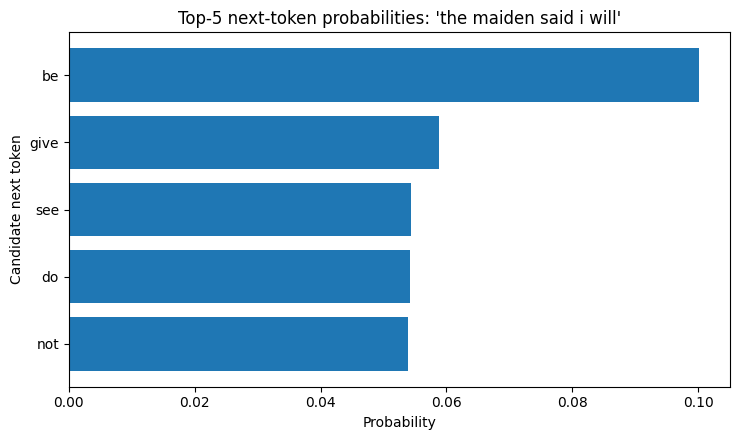

In [74]:
# TODO 4 - Next-token prediction
prompts = [
    "the maiden said i will",
    "the hare went into",
    "the king of uganda was",
]

prediction_results = {}

for prompt in prompts:
    result = top_predictions(prompt, k=5, temperature=1.0)
    prediction_results[prompt] = result

    print("=" * 70)
    print("Prompt:", prompt)
    print("Top five predicted tokens:")
    display(result)

# Create a probability bar chart for the first prompt.
plot_prompt = prompts[0]
plot_df = prediction_results[plot_prompt].sort_values("probability", ascending=True)

plt.figure(figsize=(7.5, 4.5))
plt.barh(plot_df["token"], plot_df["probability"])
plt.xlabel("Probability")
plt.ylabel("Candidate next token")
plt.title(f"Top-5 next-token probabilities: {plot_prompt!r}")
plt.tight_layout()
plt.show()


### TODO 4 explanation

The three prompts are appropriate to the corpus because they use words and narrative patterns found in the stories.

- For **“the maiden said i will”**, candidates such as `be`, `give`, `see`, `do`, and `not` are plausible grammatical continuations of a first-person statement.
- For **“the hare went into”**, `the` is strongly predicted, followed by `her`, `a`, `his`, and `him`; these are plausible continuations after the preposition `into` in the story-style corpus.
- For **“the king of uganda was”**, `a`, `the`, `very`, `one`, and `,` are plausible next-token candidates, although the probabilities are more distributed.

These are **probabilistic predictions**, not guarantees that a candidate is factually or narratively correct. The probability bar chart shows the model's relative confidence among vocabulary candidates.


## TODO 5 - Generate a short pseudo-folktale

Use the same prompt and generate approximately **80–100 new tokens** at:

$$
T=0.4
$$

and

$$
T=1.2
$$

Compare the outputs.

Discuss:

- repetition;
- grammatical coherence;
- vocabulary variety;
- evidence of corpus-like language;
- at least one obvious failure.

Explain **what temperature changed** and **what it did not change**.

In [49]:
# TODO 5 - YOUR CODE HERE

In [75]:
# TODO 5 - Generate a short pseudo-folktale
generation_prompt = "once upon a time"
generation_seed = 123
generation_top_k = 20
generation_tokens = 90

generated_at_04 = generate_text(
    generation_prompt,
    new_tokens=generation_tokens,
    temperature=0.4,
    top_k=generation_top_k,
    seed=generation_seed,
)

generated_at_12 = generate_text(
    generation_prompt,
    new_tokens=generation_tokens,
    temperature=1.2,
    top_k=generation_top_k,
    seed=generation_seed,
)

print("=" * 90)
print("TEMPERATURE = 0.4 | 90 new tokens")
print(generated_at_04)

print("\n" + "=" * 90)
print("TEMPERATURE = 1.2 | 90 new tokens")
print(generated_at_12)

# Simple evidence table: diversity and repetition in the generated continuations.
def generation_summary(text):
    toks = tokenize(text)
    counts = Counter(toks)
    return {
        "total_tokens_in_output": len(toks),
        "unique_tokens": len(counts),
        "unique_ratio": len(counts) / max(1, len(toks)),
        "most_common_token": counts.most_common(1)[0][0],
        "most_common_frequency": counts.most_common(1)[0][1],
    }

temperature_comparison = pd.DataFrame([
    {"temperature": 0.4, **generation_summary(generated_at_04)},
    {"temperature": 1.2, **generation_summary(generated_at_12)},
])
display(temperature_comparison)


TEMPERATURE = 0.4 | 90 new tokens
once upon a time the girl he had been a great feast, and the girl was very much, and the girl was so frightened that he was a good, and the girl was a good and made a long way and all the mother said: "i have you to a little girl, and the girl was a big bunch of the forest, and the woman took a great feast, and the mother are animals in the forest, and he was very hungry, and the

TEMPERATURE = 1.2 | 90 new tokens
once upon a time the leopard are of his reed and told the capital. "what had it know to do." he cried, "said the young who has very much, and at once he thought to the great the forest of the forest." i will be them. he had seen this. he had been kind the tree. "i can have been you are by your cave, for now a large heart." i have the heart to take it?


,temperature,total_tokens_in_output,unique_tokens,unique_ratio,most_common_token,most_common_frequency
0,0.4,94,43,0.457447,the,11
1,1.2,94,55,0.585106,the,8


### TODO 5 comparison

**Repetition:** At **T = 0.4**, the output is more concentrated and repeats familiar constructions such as `the girl`, `the forest`, and `great`. At **T = 1.2**, the output uses a wider variety of less-probable words and constructions.

**Grammatical coherence:** The lower-temperature sample is generally more predictable and locally stable, while the higher-temperature sample contains more grammatical and narrative breakdowns.

**Vocabulary variety:** The higher temperature increases variety because lower-probability candidates receive more sampling opportunity.

**Corpus-like language:** Both outputs contain recurring folklore vocabulary and narrative patterns such as `girl`, `forest`, `leopard`, `heart`, `tree`, and dialogue-like forms.

**Obvious failure:** The T = 1.2 sample contains awkward constructions such as **“i will be them”** and other combinations that do not form a coherent story.

**What temperature changed:** It changed the concentration of the sampling probability distribution before the next token was sampled. Lower temperature makes high-probability choices dominate; higher temperature makes the distribution flatter.

**What temperature did not change:** It did **not** retrain the LSTM, change its learned weights, change the corpus, or change the model architecture. In this comparison, `top_k` was kept fixed at 20.


## TODO 6 - One controlled experiment

Change **exactly one** factor and keep the others fixed.

**Recommended for this 90-minute practical:** change `top_k` during generation (for example, compare `top_k=5` with `top_k=30`) while keeping the prompt, temperature, seed and number of generated tokens the same.

If you have enough time, you may instead retrain a small model while changing exactly one of:
- sequence length;
- hidden size;
- number of training epochs.

Record the before/after result and answer:

> **What changed, and what evidence supports your conclusion?**

A controlled experiment changes one main factor so that the comparison has a clearer interpretation.

In [50]:
# TODO 6 - YOUR CODE HERE
# Recommended quick experiment:
# prompt = "once upon a time"
# print(generate_text(prompt, new_tokens=80, temperature=0.8, top_k=5,  seed=123))
# print(generate_text(prompt, new_tokens=80, temperature=0.8, top_k=30, seed=123))
# Then explain the comparison in a Markdown cell.


In [76]:
# TODO 6 - One controlled experiment
# We change ONLY top_k. Prompt, temperature, seed and number of generated tokens stay fixed.
experiment_prompt = "once upon a time"
experiment_temperature = 0.8
experiment_seed = 123
experiment_new_tokens = 80

generated_top5 = generate_text(
    experiment_prompt,
    new_tokens=experiment_new_tokens,
    temperature=experiment_temperature,
    top_k=5,
    seed=experiment_seed,
)

generated_top30 = generate_text(
    experiment_prompt,
    new_tokens=experiment_new_tokens,
    temperature=experiment_temperature,
    top_k=30,
    seed=experiment_seed,
)

print("=" * 90)
print("CONTROL: top_k = 5")
print(generated_top5)

print("\n" + "=" * 90)
print("CONTROL: top_k = 30")
print(generated_top30)

experiment_table = pd.DataFrame([
    {"top_k": 5, **generation_summary(generated_top5)},
    {"top_k": 30, **generation_summary(generated_top30)},
])
display(experiment_table)


CONTROL: top_k = 5
once upon a time the hare gave the river fairy, and the old granny had seen a beautiful of food and the river fairy, for she saw the river fairy, and the dog was so inquisitive, and he had been a great feast, and he was a little of food. "so the leopard was so inquisitive the river fairy," i will give it? "i will come to you. "the girl

CONTROL: top_k = 30
once upon a time the mother animals. the owl had been bewitched: "and the girl is so, but they could see that her mother is very angry, and the mother were very good and at once for the little girl was very unhappy, and the girl would not a beautiful barkcloth, and the chief had not a cave and hungry he was walking to eat the mabira forest and was a big dinner. he was quite


,top_k,total_tokens_in_output,unique_tokens,unique_ratio,most_common_token,most_common_frequency
0,5,83,42,0.506024,the,9
1,30,84,50,0.595238,the,8


### TODO 6 conclusion

Only **top_k** was changed: it was increased from **5 to 30**. The prompt, temperature (0.8), random seed (123), and requested length (80 new tokens) were kept fixed.

With **top_k = 5**, the sampling is restricted to five high-scoring candidates at every step. The generated text is therefore more constrained and shows repeated phrases such as `river fairy`, `food`, and related familiar constructions.

With **top_k = 30**, the model can sample from a much larger candidate set. The output shows greater vocabulary variety, but it also becomes less predictable and contains more awkward combinations.

**Evidence:** the generated texts and the displayed comparison table provide direct before/after evidence. Because only top_k changed, the difference can reasonably be attributed to the size of the candidate set rather than to retraining or a change in temperature.


## Final written submission - 200 to 300 words

Explain how this notebook transforms raw story text into generated text.

Your explanation must correctly use all of these terms:

**corpus, token, token ID, vocabulary, embedding, sequence, LSTM, hidden state, cell state, gate, training, next-token probability, generation**

Also include one sentence explaining why the generated text does **not** prove that the model understands the folklore in the human sense.

## Final self-check

Before submitting, can you answer these without looking back?

1. Why is language sequential?
2. Why isn't a token ID an embedding?
3. What information influences $h_t$?
4. What extra mechanism does an LSTM add beyond a basic RNN?
5. Why did we split by whole story?
6. Why is the model's output a probability distribution?
7. How does next-token prediction become generation?
8. Why does temperature change generation without retraining?
9. Why can a model produce plausible language without factual or cultural understanding?

If any answer is unclear, return to the relevant section before submitting.

## Final self-check — answers

1. **Why is language sequential?**  
   The order of tokens matters because the meaning and likely next token depend on the preceding context. Reordering tokens can change the meaning and the prediction task.

2. **Why isn't a token ID an embedding?**  
   A token ID is only an integer index used to identify a vocabulary item. An embedding is a learned vector of numerical values associated with that ID.

3. **What information influences \(h_t\)?**  
   The current input \(x_t\) and the previous hidden/cell information processed by the LSTM influence the new hidden state \(h_t\). Therefore, earlier context can affect later states.

4. **What extra mechanism does an LSTM add beyond a basic RNN?**  
   An LSTM adds a separate cell state and learned gates—forget, input and output gates—to control information flow.

5. **Why did we split by whole story?**  
   To prevent overlapping or very similar windows from the same story appearing in both training and evaluation. This gives a cleaner test of generalisation to unseen stories.

6. **Why is the model's output a probability distribution?**  
   The final linear layer gives one logit for each vocabulary token. Softmax converts those scores into probabilities that sum to 1, allowing the model to represent uncertainty among possible next tokens.

7. **How does next-token prediction become generation?**  
   Predict one next token, select/sample it, append it to the context, and use the extended context to predict the following token. Repeating this process produces a sequence of generated text.

8. **Why does temperature change generation without retraining?**  
   Temperature rescales the logits before sampling. It changes the sampling distribution but does not change the learned model parameters.

9. **Why can a model produce plausible language without factual or cultural understanding?**  
   The model learns statistical patterns in the training text. It can reproduce familiar vocabulary and structures without possessing human-like understanding, grounded knowledge, or reliable factual reasoning.
